In [1]:
import pandas as pd
import numpy as np

# Loading data
PATH = "Airline_dataset.csv"   # adjust if needed
df = pd.read_csv(PATH, low_memory=False)

# Basic shape and columns
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# If you expect a date column, coerce it (optional)
for col in df.columns:
    if "date" in col.lower():
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Types, memory, head, sample
print("\nDtypes:")
print(df.dtypes)
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"\nMemory usage: {mem_mb:.2f} MB")

display(df.head(10))        
display(df.sample(5, random_state=0))

# Missing values analysis
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(df)).round(4)
na_table = pd.DataFrame({"missing": na_counts, "missing_pct": na_pct})
print("\nMissing values (top 20):")
display(na_table.head(20))

# Duplicates analysis
dup_rows = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_rows}")

# Quick numeric / categorical overview
print("\nNumeric describe:")
display(df.select_dtypes(include=np.number).describe().T)

print("\nCategorical describe (top-level stats):")
display(df.select_dtypes(exclude=np.number).describe().T)

# Top categories for first few object columns
obj_cols = df.select_dtypes(exclude=np.number).columns[:5]
for c in obj_cols:
    print(f"\nTop values for '{c}':")
    display(df[c].value_counts(dropna=False).head(10))

# Quick checks often useful
# Unique counts per column (helps spot IDs vs categories)
uniq = df.nunique(dropna=False).sort_values(ascending=False)
print("\nUnique counts per column (top 20):")
display(uniq.head(20))

# If delay columns exist, preview simple stats (adjust names if different)
candidate_delay_cols = [c for c in df.columns if "delay" in c.lower()]
if candidate_delay_cols:
    print("\nDelay columns found:", candidate_delay_cols)
    display(
        df[candidate_delay_cols].describe(percentiles=[.5, .75, .9, .95, .99]).T
    )


Shape: (1204825, 14)

Columns: ['Unnamed: 0', 'FL_DATE', 'AIRLINE_ID', 'TAIL_NUM', 'FLIGHT_NUM', 'ORIGIN_SEQ_ID', 'ORIGIN_AIRPORT', 'DEST_SEQ_ID', 'DEST_AIRPORT', 'DEP_TIME', 'DEP_DELAY', 'ARR_TIME', 'ARR_DELAY', 'WEATHER_DELAY']

Dtypes:
Unnamed: 0                 int64
FL_DATE           datetime64[ns]
AIRLINE_ID               float64
TAIL_NUM                  object
FLIGHT_NUM               float64
ORIGIN_SEQ_ID            float64
ORIGIN_AIRPORT            object
DEST_SEQ_ID              float64
DEST_AIRPORT              object
DEP_TIME                 float64
DEP_DELAY                float64
ARR_TIME                 float64
ARR_DELAY                float64
WEATHER_DELAY            float64
dtype: object


/var/folders/wk/kkxcfs2n1zb_j6vnswy6xxgc0000gn/T/ipykernel_31144/3344363454.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")



Memory usage: 311.37 MB


,Unnamed: 0,FL_DATE,AIRLINE_ID,TAIL_NUM,FLIGHT_NUM,ORIGIN_SEQ_ID,ORIGIN_AIRPORT,DEST_SEQ_ID,DEST_AIRPORT,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,WEATHER_DELAY
0,0,2018-08-01,19805.0,N956AN,1587.0,1247805.0,JFK,1410702.0,PHX,1649.0,9.0,2006.0,44.0,0.000000
1,1,2018-08-01,19805.0,N973AN,1588.0,1410702.0,PHX,1161802.0,EWR,1541.0,29.0,2350.0,53.0,0.000000
2,2,2018-08-01,19805.0,N9006,1590.0,1104205.0,CLE,1129806.0,DFW,741.0,-3.0,938.0,-2.0,4.030195
3,3,2018-08-01,19805.0,N870NN,1591.0,1484306.0,SJU,1129806.0,DFW,944.0,44.0,1347.0,43.0,0.000000
4,4,2018-08-01,19805.0,N9023N,1593.0,1042302.0,AUS,1330303.0,MIA,556.0,-4.0,951.0,-2.0,4.030195
5,5,2018-08-01,19805.0,N924NN,1594.0,1143302.0,DTW,1393006.0,ORD,1151.0,-10.0,1224.0,-7.0,4.030195
6,6,2018-08-01,19805.0,N924NN,1594.0,1393006.0,ORD,1143302.0,DTW,849.0,-1.0,1110.0,5.0,4.030195
7,7,2018-08-01,19805.0,N905AU,1595.0,1042302.0,AUS,1129806.0,DFW,655.0,-6.0,757.0,-13.0,4.030195
8,8,2018-08-01,19805.0,N301NW,1596.0,1129806.0,DFW,1385103.0,OKC,1233.0,-2.0,1329.0,-5.0,4.030195
9,9,2018-08-01,19805.0,N301NW,1596.0,1385103.0,OKC,1129806.0,DFW,1415.0,-10.0,1530.0,1.0,4.030195


,Unnamed: 0,FL_DATE,AIRLINE_ID,TAIL_NUM,FLIGHT_NUM,ORIGIN_SEQ_ID,ORIGIN_AIRPORT,DEST_SEQ_ID,DEST_AIRPORT,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,WEATHER_DELAY
1147390,1167850,2020-01-16,19790.0,N817NW,559.0,1039707.0,ATL,1484306.0,SJU,940.0,0.0,1410.0,-5.0,4.030195
715971,730781,2020-01-27,19930.0,N581AS,820.0,1383002.0,OGG,1474703.0,SEA,1157.0,-3.0,1942.0,-3.0,4.030195
199747,206130,2018-08-09,19393.0,N939WN,2189.0,1483106.0,SJC,1288903.0,LAS,705.0,-5.0,826.0,-4.0,4.030195
885914,903107,2020-01-02,19790.0,N386DA,1468.0,1119302.0,CVG,1530402.0,TPA,719.0,14.0,920.0,-9.0,4.030195
148607,153391,2018-08-07,19805.0,N917UY,514.0,1129806.0,DFW,1105703.0,CLT,1209.0,-6.0,1547.0,-4.0,4.030195


...

DEST_AIRPORT
ATL    63801
ORD    55346
DFW    44344
DEN    42123
CLT    37995
LAX    37830
PHX    27983
IAH    27951
DTW    27499
SFO    27339
Name: count, dtype: int64


Unique counts per column (top 20):


Unnamed: 0        1204825
FLIGHT_NUM           7027
TAIL_NUM             6266
ARR_TIME             1440
DEP_TIME             1439
ARR_DELAY            1085
DEP_DELAY            1053
WEATHER_DELAY         444
ORIGIN_SEQ_ID         409
DEST_SEQ_ID           409
ORIGIN_AIRPORT        375
DEST_AIRPORT          375
FL_DATE                62
AIRLINE_ID             26
dtype: int64


Delay columns found: ['DEP_DELAY', 'ARR_DELAY', 'WEATHER_DELAY']


,count,mean,std,min,50%,75%,90%,95%,99%,max
DEP_DELAY,1204247.0,6.839347,40.084812,-58.0,-3.000000,3.000000,25.000000,59.000000,171.000000,1855.0
ARR_DELAY,1201443.0,0.539073,42.655998,-96.0,-8.000000,3.000000,25.000000,61.000000,172.000000,1843.0
WEATHER_DELAY,1204825.0,4.030195,10.131137,0.0,4.030195,4.030195,4.030195,4.030195,4.030195,1165.0


In [2]:
# What are the max and min times in FL_DATE?
if 'FL_DATE' in df.columns:
    min_date = df['FL_DATE'].min()
    max_date = df['FL_DATE'].max()
    print(f"\nDate range in 'FL_DATE': {min_date} to {max_date}")


Date range in 'FL_DATE': 2018-08-01 00:00:00 to 2020-01-31 00:00:00


The busiest airport as we can see if Atlanta, we will thus focus on this airport, and we will now choose a specific day to analyse for our problem.

Okay so now we ran into a logical problem, our sorting is flawed, we will do the matching again, differently.

In [3]:
import pandas as pd

df_new = df.copy()

# Keep only ATL-related flights
df_atl = df_new[(df_new["ORIGIN_AIRPORT"] == "ATL") | (df_new["DEST_AIRPORT"] == "ATL")].copy()
df_atl = df_atl[df_atl["FL_DATE"] == "2020-01-15"].copy()

# Ensure ordering
df_atl = df_atl.sort_values(["TAIL_NUM", "FL_DATE", "DEP_TIME", "ARR_TIME"])

pairs = []

for tail, group in df_atl.groupby("TAIL_NUM"):
    # arrivals into ATL
    arrs = group[group["DEST_AIRPORT"] == "ATL"].sort_values("ARR_TIME")
    # departures from ATL
    deps = group[group["ORIGIN_AIRPORT"] == "ATL"].sort_values("DEP_TIME")
    
    # convert to lists we can consume
    dep_list = deps.to_dict("records")

    for _, arr in arrs.iterrows():
        arr_time = arr["ARR_TIME"]

        # find the first departure strictly after this arrival
        next_dep_idx = None
        for i, d in enumerate(dep_list):
            if d["DEP_TIME"] > arr_time:
                next_dep_idx = i
                break

        if next_dep_idx is None:
            continue  # no departure after arrival → overnight or last leg
        
        dep = dep_list.pop(next_dep_idx)  # consume the departure so it can't be reused

        pairs.append({
            "FL_DATE": arr["FL_DATE"],
            "TAIL_NUM": tail,
            "from_airport": arr["ORIGIN_AIRPORT"],
            "in_flight_num": arr["FLIGHT_NUM"],
            "arr_at_ATL_time": arr["ARR_TIME"],
            "to_airport": dep["DEST_AIRPORT"],
            "out_flight_num": dep["FLIGHT_NUM"],
            "dep_from_ATL_time": dep["DEP_TIME"]
        })

# Build final clean dataframe
visits = pd.DataFrame(pairs).sort_values(["TAIL_NUM", "arr_at_ATL_time"]).reset_index(drop=True)


In [4]:
visits.head()
visits["FL_DATE"].max()

Timestamp('2020-01-15 00:00:00')

In [5]:
# Now check that the logic stands, departure after arrival, when on the same FL_DATE 
invalid_times = visits[visits["dep_from_ATL_time"] <= visits["arr_at_ATL_time"]]
print("Number of visits with invalid times (dep <= arr):", len(invalid_times))  


Number of visits with invalid times (dep <= arr): 0


In [6]:
# Shape of our visits dataframe
print("Shape of visits dataframe:", visits.shape)



Shape of visits dataframe: (868, 8)


In [7]:
# converting numeric columns to datetimes

import pandas as pd

# --- Assume visits looks like the table you showed ---
# columns: FL_DATE, TAIL_NUM, from_airport, in_flight_num, arr_at_ATL_time,
#          to_airport, out_flight_num, dep_from_ATL_time

def hhmm_int_to_minutes(t):
    """
    Convert an integer like 1209 -> minutes since midnight = 12*60 + 9 = 729.
    Assumes t is HHMM in local time.
    """
    t = int(t)
    hour = t // 100
    minute = t % 100
    return hour * 60 + minute

# 1) Convert FL_DATE to a proper date
visits["FL_DATE"] = pd.to_datetime(visits["FL_DATE"])

# 2) Create minutes-since-midnight columns
visits["arr_min"] = visits["arr_at_ATL_time"].apply(hhmm_int_to_minutes)
visits["dep_min"] = visits["dep_from_ATL_time"].apply(hhmm_int_to_minutes)

# 3) Create full datetime columns (date + time)
visits["arr_dt"] = visits["FL_DATE"] + pd.to_timedelta(visits["arr_min"], unit="m")
visits["dep_dt"] = visits["FL_DATE"] + pd.to_timedelta(visits["dep_min"], unit="m")

# 4) Turnaround time in minutes (how long the plane sits at a gate)
visits["turn_minutes"] = (visits["dep_dt"] - visits["arr_dt"]).dt.total_seconds() / 60


In [8]:
visits.head()

,FL_DATE,TAIL_NUM,from_airport,in_flight_num,arr_at_ATL_time,to_airport,out_flight_num,dep_from_ATL_time,arr_min,dep_min,arr_dt,dep_dt,turn_minutes
0,2020-01-15,N109HQ,PHL,4273.0,1209.0,PHL,4273.0,1253.0,729,773,2020-01-15 12:09:00,2020-01-15 12:53:00,44.0
1,2020-01-15,N120HQ,PHL,4426.0,1314.0,PHL,4426.0,1428.0,794,868,2020-01-15 13:14:00,2020-01-15 14:28:00,74.0
2,2020-01-15,N132EV,CAE,5303.0,925.0,HSV,4759.0,956.0,565,596,2020-01-15 09:25:00,2020-01-15 09:56:00,31.0
3,2020-01-15,N132EV,HSV,4759.0,1231.0,GPT,5236.0,1336.0,751,816,2020-01-15 12:31:00,2020-01-15 13:36:00,65.0
4,2020-01-15,N132EV,GPT,5236.0,1658.0,TLH,5278.0,1757.0,1018,1077,2020-01-15 16:58:00,2020-01-15 17:57:00,59.0


We can see on the internet that there a 192 different gates, we will.

## Synthetic Data

ATL handles ~2100 flights/day across ~190 gates (~11 flights/gate/day).
Our instance has 868 ATL visits, which we assign over 36 modeled gates (~24 flights/gate/day), representing a particularly busy terminal or concourse cluster rather than the entire airport. And we choose to have 5 tugs available.

We will now do the distance matrix between each gate, we consider it is symmetrical, normally distributed with N(7,2), in minutes, and we consider entries on diagonal are 1 min (from gate to same gate).

In [9]:
import pandas as pd
import numpy as np

# ----- PARAMETERS -----
N_GATES = 36
gate_ids = [f"G{i}" for i in range(1, N_GATES + 1)]
gates = pd.DataFrame({
    "gate_id": gate_ids
})

np.random.seed(42)

# Initialize empty matrix
M = np.zeros((N_GATES, N_GATES))

# Fill upper triangular (excluding diagonal)
for i in range(N_GATES):
    for j in range(i+1, N_GATES):
        travel = np.random.normal(loc=7.0, scale=2.0)
        travel = max(1.0, travel)   # clip minimum to 1
        M[i, j] = travel
        M[j, i] = travel            # symmetric

# Set diagonal to 1 minute
np.fill_diagonal(M, 1.0)

# Convert to long dataframe
rows = []
for i, g1 in enumerate(gate_ids):
    for j, g2 in enumerate(gate_ids):
        rows.append({
            "from_gate": g1,
            "to_gate": g2,
            "travel_min": round(float(M[i, j]), 2)
        })

gate_travel_times = pd.DataFrame(rows)

gate_travel_times.head()


,from_gate,to_gate,travel_min
0,G1,G1,1.00
1,G1,G2,7.99
2,G1,G3,6.72
3,G1,G4,8.30
4,G1,G5,10.05


In [10]:
travel_time = {
    (row.from_gate, row.to_gate): row.travel_min
    for row in gate_travel_times.itertuples(index=False)
}

In [11]:
visits = visits.rename(columns={
    "arr_min": "arr",
    "dep_min": "dep"
})

# create unique identifier for each visit
visits["visit_id"] = visits.index.astype(str)
visits.shape



(868, 14)

##### Creating subset on 2 hour subset

In [12]:
import numpy as np

# -------------------------------------------------------------------
# 1) Choose the 1-hour window in MINUTES since midnight
#    (adjust these two numbers only)
# -------------------------------------------------------------------
WINDOW_START_MIN = 16 * 60   # 13:00 → 780
WINDOW_END_MIN   = 20 * 60  # 13:30 → 810

print(
    f"4-hour window: "
    f"{int(WINDOW_START_MIN//60):02d}:{int(WINDOW_START_MIN%60):02d} - "
    f"{int(WINDOW_END_MIN//60):02d}:{int(WINDOW_END_MIN%60):02d}"
)
# -------------------------------------------------------------------
# 2) Subset visits: keep flights whose [arr, dep] overlaps the window
#    Condition: arr < END and dep > START
# -------------------------------------------------------------------
mask_window = (
    (visits["arr"] < WINDOW_END_MIN) &
    (visits["dep"] > WINDOW_START_MIN)
)

visits_sub = visits.loc[mask_window].copy().reset_index(drop=True)

print("Original number of visits:", len(visits))
print("Visits in 4-hour window:", len(visits_sub))

# -------------------------------------------------------------------
# 3) Rebuild visit_id for the subset (string index),
#    keep the same time convention (minutes since midnight)
# -------------------------------------------------------------------
visits_sub["visit_id"] = visits_sub.index.astype(str)

# This is the MILP-ready view for the subset: same structure as visits_milp
visits_milp_sub = visits_sub[["visit_id", "arr", "dep"]].copy()

# -------------------------------------------------------------------
# 4) Remote-right column for the subset (same logic as your big model)
# -------------------------------------------------------------------
np.random.seed(42)  # keep consistent behaviour
visits_milp_sub["remote_right"] = np.random.choice(
    [0, 1],
    size=len(visits_milp_sub),
    p=[0, 1]  # same as in your notebook (you can change if you fix it there)
)

print(visits_milp_sub.head())

# -------------------------------------------------------------------
# 5) Tug tasks for the subset (same structure as your original tug_tasks)
# -------------------------------------------------------------------
TASK_DURATION = 7  # minutes tug is busy before departure (same as before)

tug_tasks_sub = visits_milp_sub.copy()
tug_tasks_sub["task_id"]    = range(len(tug_tasks_sub))
tug_tasks_sub["task_start"] = tug_tasks_sub["dep"] - TASK_DURATION
tug_tasks_sub["task_end"]   = tug_tasks_sub["dep"]

tug_tasks_sub = tug_tasks_sub[["task_id", "visit_id", "task_start", "task_end"]]

print("Tug tasks (subset):")
print(tug_tasks_sub.head())
print("Shape tug_tasks_sub:", tug_tasks_sub.shape)

# -------------------------------------------------------------------
# 6) Flight index set for the MILP on the subset
# -------------------------------------------------------------------
flights_sub = list(visits_milp_sub["visit_id"])
print("Number of flights in subset (for MILP):", len(flights_sub))


4-hour window: 16:00 - 20:00
Original number of visits: 868
Visits in 4-hour window: 320
  visit_id   arr   dep  remote_right
0        0  1018  1077             1
1        1  1165  1240             1
2        2   976  1027             1
3        3   769  1140             1
4        4  1024  1150             1
Tug tasks (subset):
   task_id visit_id  task_start  task_end
0        0        0        1070      1077
1        1        1        1233      1240
2        2        2        1020      1027
3        3        3        1133      1140
4        4        4        1143      1150
Shape tug_tasks_sub: (320, 4)
Number of flights in subset (for MILP): 320


In [13]:
# Now we take a random subset of flights of flights sub, to keep 40 flights total

np.random.seed(42)
if len(flights_sub) > 35:
    selected_flights = np.random.choice(flights_sub, size=35, replace=False)

    flights_sub = list(selected_flights)

    visits_milp_sub = (
        visits_milp_sub[visits_milp_sub["visit_id"].isin(flights_sub)]
        .reset_index(drop=True)
    )
    tug_tasks_sub = (
        tug_tasks_sub[tug_tasks_sub["visit_id"].isin(flights_sub)]
        .reset_index(drop=True)
    )

    # IMPORTANT: rebuild flights_sub from the filtered table (clean list)
    flights_sub = list(visits_milp_sub["visit_id"])
    print("Final |F_sub|:", len(flights_sub))
    print("Shape visits_milp_sub after filtering:", visits_milp_sub.shape)

Final |F_sub|: 35
Shape visits_milp_sub after filtering: (35, 4)


In [14]:
# Rebuild arr/dep dicts for the NEW 40 flights
arr_sub = visits_milp_sub.set_index("visit_id")["arr"].to_dict()
dep_sub = visits_milp_sub.set_index("visit_id")["dep"].to_dict()
dep_sched_sub = dep_sub  # or your alternative schedule

# Recompute overlap pairs for the NEW flights
subset_overlap_pairs = []
for i, f1 in enumerate(flights_sub):
    for f2 in flights_sub[i + 1:]:
        if arr_sub[f1] < dep_sub[f2] and arr_sub[f2] < dep_sub[f1]:
            subset_overlap_pairs.append((f1, f2))

print("Subset gate-overlap pairs (new):", len(subset_overlap_pairs))

Subset gate-overlap pairs (new): 288


In [15]:
# Whats the average difference between arrival and departure in the the whole set?
avg_turnaround = visits["turn_minutes"].mean()
print(f"Average turnaround time (all visits): {avg_turnaround:.2f} minutes")

Average turnaround time (all visits): 105.91 minutes


In [13]:
cols_to_keep = [
    "visit_id",
    "TAIL_NUM",
    "from_airport",
    "to_airport",
    "arr",        # minutes since midnight → MILP
    "dep",        # minutes since midnight → MILP
    "turn_minutes",
    "arr_dt",     # optional for debugging
    "dep_dt"      # optional for debugging
]

visits_clean = visits[cols_to_keep].copy()
visits_clean.head()
visits_clean.shape

(868, 9)

## MILP without tugs

In [14]:
visits_milp = visits[["visit_id", "arr", "dep"]].copy()

Some visits will have the right to use a remote stand with probability 0.4, we will incorporate it as a column of visits_milp

In [15]:
import numpy as np

# visits_milp has at least: visit_id, arr, dep
np.random.seed(42)  # reproducible

visits_milp["remote_right"] = np.random.choice(
    [0, 1],
    size=len(visits_milp),
    p=[0, 1]   # 40% of flights are allowed to go "no gate / remote"
)

visits_milp.head()


,visit_id,arr,dep,remote_right
0,0,729,773,1
1,1,794,868,1
2,2,565,596,1
3,3,751,816,1
4,4,1018,1077,1


### Gate assignment model with no-gate (remote) option

We consider a set of flights and a set of gates. Some flights are allowed to **not use a gate** (e.g. parked remotely and bussed) at a penalty cost. The model chooses, for each flight, either a gate or the remote option.

#### Sets

- $F$: set of flights.
- $G$: set of gates.
- $\mathcal{O} \subseteq F \times F$: set of pairs of flights whose time intervals overlap.

#### Parameters

- $a_f$: arrival time of flight $f$ at ATL (minutes since midnight), for all $f \in F$.
- $d_f$: scheduled departure (pushback) time of flight $f$ (minutes since midnight), for all $f \in F$.
- $r_f \in \{0,1\}$: indicator that flight $f$ is allowed to use the no-gate (remote) option ($r_f = 1$) or not ($r_f = 0$).
- $C_{\text{remote}} > 0$: cost (penalty) of sending one flight to the no-gate option.

Two flights $f$ and $f'$ are said to overlap if their time intervals intersect:
$$
[a_f, d_f] \cap [a_{f'}, d_{f'}] \neq \emptyset.
$$
All such pairs are collected into $\mathcal{O}$.

#### Decision variables

For all $f \in F$ and $g \in G$:
$$
x_{f,g} =
\begin{cases}
1 & \text{if flight } f \text{ is assigned to gate } g, \\
0 & \text{otherwise.}
\end{cases}
$$

For all $f \in F$:
$$
y_f =
\begin{cases}
1 & \text{if flight } f \text{ uses the no-gate (remote) option}, \\
0 & \text{otherwise.}
\end{cases}
$$

Here $y_f = 1$ means the flight does **not** occupy any gate and is instead handled remotely. Using this option incurs a cost.

#### Objective function

We penalize the use of the no-gate option. The objective is:
$$
\min \sum_{f \in F} C_{\text{remote}} \, y_f.
$$

So each flight sent to the remote option costs $C_{\text{remote}}$ units. If a flight uses a gate (some $x_{f,g} = 1$), then $y_f = 0$ and no penalty is paid for that flight.

#### Constraints

1. **Each flight chooses exactly one option (gate or remote)**

For each flight, we must either assign it to exactly one gate or send it to the remote option:
$$
\sum_{g \in G} x_{f,g} + y_f = 1
\qquad \forall f \in F.
$$

2. **Remote option allowed only when permitted**

If $r_f = 0$, the flight is not allowed to use the no-gate option, so $y_f$ must be zero:
$$
y_f \le r_f
\qquad \forall f \in F.
$$

3. **No two overlapping flights can share a gate**

If two flights overlap in time, they cannot occupy the same gate:
$$
x_{f,g} + x_{f',g} \le 1
\qquad \forall (f,f') \in \mathcal{O}, \; \forall g \in G.
$$

This enforces that overlapping flights never use the same gate at the same time, while still allowing the model to “release pressure” on the gate system by paying $C_{\text{remote}}$ for some flights and sending them to the remote option.


In [18]:
# making the keys consistent
# Ensure types are clean
visits_milp["visit_id"] = visits_milp["visit_id"].astype(int)
visits_milp["arr"] = visits_milp["arr"].astype(int)
visits_milp["dep"] = visits_milp["dep"].astype(int)

# Build lists/dicts for fast access
flights = list(visits_milp["visit_id"])
arr = visits_milp.set_index("visit_id")["arr"].to_dict()
dep = visits_milp.set_index("visit_id")["dep"].to_dict()

print("Example flight:", flights[0], type(flights[0]))
print("Example arr key:", list(arr.keys())[0], type(list(arr.keys())[0]))


Example flight: 0 <class 'int'>
Example arr key: 0 <class 'int'>


In [19]:
# Flights that overlap

overlap_pairs = []

for i in range(len(flights)):
    f1 = flights[i]
    a1, d1 = arr[f1], dep[f1]
    
    for j in range(i + 1, len(flights)):
        f2 = flights[j]
        a2, d2 = arr[f2], dep[f2]
        
        # intervals [a1, d1] and [a2, d2] overlap?
        if not (d1 <= a2 or d2 <= a1):
            overlap_pairs.append((f1, f2))

        

print("Total overlap pairs (no window):", len(overlap_pairs))
print("First few pairs:", overlap_pairs[:10])


print("Proportion of overlapping pairs :", len(overlap_pairs) / (len(flights)*(len(flights)-1)/2)*100, "%")

Total overlap pairs (no window): 82558
First few pairs: [(0, 3), (0, 8), (0, 12), (0, 21), (0, 23), (0, 27), (0, 46), (0, 48), (0, 49), (0, 57)]
Proportion of overlapping pairs : 21.94069278565316 %


In [20]:
import gurobipy as gp
from gurobipy import GRB


#  Data extraction


flights = list(visits_milp["visit_id"])
gates_list = list(gates["gate_id"])

arr = visits_milp.set_index("visit_id")["arr"].to_dict()
dep = visits_milp.set_index("visit_id")["dep"].to_dict()
remote_right = visits_milp.set_index("visit_id")["remote_right"].to_dict()  # r_f

# Precompute overlapping pairs O

# Penalty for using the no-gate option
C_REMOTE = 20.0

#  Model


m = gp.Model("GateAssignment_NoGateOption")
m.setParam("LogToConsole", 1)       # print logs to notebook/terminal
m.setParam("DisplayInterval", 1) 

# x[f,g] = 1 if flight f uses gate g
x = m.addVars(flights, gates_list, vtype=GRB.BINARY, name="x")

# y[f] = 1 if flight f uses no-gate (remote) option
y = m.addVars(flights, vtype=GRB.BINARY, name="y")

# 1) Each flight chooses gate or remote
for f in flights:
    m.addConstr(
        gp.quicksum(x[f, g] for g in gates_list) + y[f] == 1,
        name=f"assign_or_remote_{f}",
    )

# 2) Remote only if allowed: y_f <= r_f
for f in flights:
    m.addConstr(
        y[f] <= remote_right[f],
        name=f"remote_allowed_{f}",
    )

# 3) No overlapping flights on the same gate
for f1, f2 in overlap_pairs:
    for g in gates_list:
        m.addConstr(
            x[f1, g] + x[f2, g] <= 1,
            name=f"no_overlap_{f1}_{f2}_{g}",
        )

# Objective: minimize total remote usage cost
m.setObjective(
    gp.quicksum(C_REMOTE * y[f] for f in flights),
    GRB.MINIMIZE,
)

m.optimize()


Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-23
Set parameter LogToConsole to value 1
Set parameter DisplayInterval to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[rosetta2] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
DisplayInterval  1

Optimize a model with 2973824 rows, 32116 columns and 5977160 nonzeros
Model fingerprint: 0x56f722c6
Variable types: 0 continuous, 32116 integer (32116 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 10340.000000
Presolve removed 868 rows and 0 columns (presolve time = 1s)...
Presolve removed 2902036 rows and 0 columns
Presolve time: 1.76s
Presolved: 71788 rows, 32116 columns, 902200 nonzeros
Variable types: 0 continuous, 32116 integer 

### Checking why model is infeasible

In [21]:
import numpy as np

# assume visits_milp has: arr, dep (minutes), remote_right
arr = visits_milp.set_index("visit_id")["arr"].to_dict()
dep = visits_milp.set_index("visit_id")["dep"].to_dict()
rr  = visits_milp.set_index("visit_id")["remote_right"].to_dict()

flights = list(visits_milp["visit_id"])
num_gates = len(gates_list)

t_min = min(arr.values())
t_max = max(dep.values())

worst = 0
worst_t = None

for t in range(t_min, t_max + 1):
    # flights on ground at time t
    active = [f for f in flights if arr[f] <= t < dep[f]]
    # among those, flights that are NOT allowed to go remote
    active_forced_gate = [f for f in active if rr[f] == 0]
    cnt = len(active_forced_gate)
    if cnt > worst:
        worst = cnt
        worst_t = t

print("Max concurrent flights forced to gate:", worst)
print("Number of gates:", num_gates)
print("Time (minutes) when worst occurs:", worst_t)


Max concurrent flights forced to gate: 0
Number of gates: 36
Time (minutes) when worst occurs: None


Which explains our case, if some of these flights are not allowed to go remote.
Btw model was infeasible with no remote gates, now that all gates are allowed to go remote, it works!

In [22]:
import pandas as pd
from gurobipy import GRB

# -----------------------------
# 1. Check model status
# -----------------------------
if m.status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print(f"Model status: {m.status}")
else:
    print("Model solved. Extracting solution...")

    # -----------------------------
    # 2. Build assignment table
    # -----------------------------
    rows = []
    for f in flights:
        # see if this flight went remote
        is_remote = 1 if y[f].X > 0.5 else 0
        
        # find assigned gate (if any)
        assigned_gate = None
        if is_remote == 0:
            for g in gates_list:
                if x[f, g].X > 0.5:
                    assigned_gate = g
                    break
        
        rows.append({
            "visit_id": f,
            "assigned_gate": assigned_gate,   # None if remote
            "remote": is_remote
        })
    
    assignments_df = pd.DataFrame(rows)
    
    # -----------------------------
    # 3. Objective value and cost
    # -----------------------------
    total_obj = m.objVal                           # objective value
    num_remote_flights = assignments_df["remote"].sum()
    total_remote_cost = num_remote_flights * C_REMOTE
    
    print(f"Objective value: {total_obj}")
    print(f"Remote flights count: {num_remote_flights}")
    print(f"Total remote cost (remote flights * C_REMOTE): {total_remote_cost}")
    
    # -----------------------------
    # 4. List flights assigned to remote
    # -----------------------------
    remote_flights_df = assignments_df[assignments_df["remote"] == 1]
    
    print("\nSample of flights sent to remote (no gate):")
    print("Proportion of flights sent to remote (no gate):", len(remote_flights_df) / len(assignments_df) * 100, "%")
    print(remote_flights_df.head())


Model solved. Extracting solution...
Objective value: 7540.0
Remote flights count: 377
Total remote cost (remote flights * C_REMOTE): 7540.0

Sample of flights sent to remote (no gate):
Proportion of flights sent to remote (no gate): 43.4331797235023 %
    visit_id assigned_gate  remote
4          4          None       1
7          7          None       1
12        12          None       1
15        15          None       1
16        16          None       1


### Insights 

Going forward we may reconsider our 36 gates thingy, as we can see a lot of our flights in our preliminary model are sent to remote.

## MILP with the tugs with no distance between the gates

In [23]:
# Defining the tugs df

N_TUGS = 5  # for now we choose to have 5 tugs

tugs = pd.DataFrame({
    "tug_id":   [f"T{i}" for i in range(1, N_TUGS + 1)],
    "home_gate": gates_list[:N_TUGS]  # eg first few gates as their starting positions
})

tugs.head()

,tug_id,home_gate
0,T1,G1
1,T2,G2
2,T3,G3
3,T4,G4
4,T5,G5


We will consider that the tug takes 6 minutes to "untug" the plane, and has to do it before the departure of the said plane.

The tug in our model has to be at the plane 6 minutes before the departure of the plane.

Another thing to note is that in our model, we consider that given a flight is assigned to remote, it does not need a tug, and the extra cost is beared completely by C in the objective function.



In [24]:
# tug tasks dataframe

TASK_DURATION = 7  # minutes tug is busy before departure

tug_tasks = visits_milp.copy()

tug_tasks["task_id"]    = range(len(tug_tasks))
tug_tasks["task_start"] = tug_tasks["dep"] - TASK_DURATION
tug_tasks["task_end"]   = tug_tasks["dep"]
tug_tasks = tug_tasks[["task_id", "visit_id", "task_start", "task_end"]]

print(tug_tasks.head())
tug_tasks.shape

   task_id  visit_id  task_start  task_end
0        0         0         766       773
1        1         1         861       868
2        2         2         589       596
3        3         3         809       816
4        4         4        1070      1077


(868, 4)

For flight visit_id, a tug would be busy from task_start to task_end **if** this flight uses a gate.

In [25]:
# Now similarly as before, we find the overlapping tug tasks
task_start = tug_tasks.set_index("visit_id")["task_start"].to_dict()
task_end   = tug_tasks.set_index("visit_id")["task_end"].to_dict()


tug_overlap_pairs = []
for i in range(len(flights)):
    f1 = flights[i]
    s1, e1 = task_start[f1], task_end[f1]
    for j in range(i + 1, len(flights)):
        f2 = flights[j]
        s2, e2 = task_start[f2], task_end[f2]
        # overlap if intervals [s1,e1] and [s2,e2] intersect
        if not (e1 <= s2 or e2 <= s1):
            tug_overlap_pairs.append((f1, f2))

print("Number of tug overlap pairs:", len(tug_overlap_pairs))
print("Proportion of tug overlapping pairs :", len(tug_overlap_pairs) / (len(flights)*(len(flights)-1)/2)*100, "%")

Number of tug overlap pairs: 5883
Proportion of tug overlapping pairs : 1.563471688485641 %


The difference between this proporton and the proportion of overlapping flight pairs is explained by the fact that the intervals for the tasks are much smaller than the interval each plane sits at a gate.

We model a single-day **gate assignment** and **tug assignment** problem at ATL.

---

### Sets

- $F$ : set of flights (visits), indexed by $f$.

- $G$ : set of gates, indexed by $g$.

- $K$ : set of tugs, indexed by $k$.

- $\mathcal{O}^{\text{gate}} \subseteq F \times F$ :  
  set of *pairs of flights* $(f_1,f_2)$ whose **on-ground intervals overlap**:
  $$
  [\text{arr}_{f_1},\ \text{dep}_{f_1}]
  \ \cap\
  [\text{arr}_{f_2},\ \text{dep}_{f_2}]
  \ \neq\ \emptyset.
  $$

- $\mathcal{O}^{\text{tug}} \subseteq F \times F$ :  
  set of *pairs of flights* $(f_1,f_2)$ whose **tug-task intervals overlap**:
  $$
  [\text{task\_start}_{f_1},\ \text{task\_end}_{f_1}]
  \ \cap\
  [\text{task\_start}_{f_2},\ \text{task\_end}_{f_2}]
  \ \neq\ \emptyset.
  $$

*(Both overlap sets are precomputed from the data.)*

---

### Parameters

- $\text{arr}_f$ : arrival time of flight $f$ at ATL (minutes after midnight).

- $\text{dep}^{\text{sched}}_f$ : **scheduled** pushback (departure) time of flight $f$.

- $\text{dep}_f$ : planned pushback time we use to build the day (often equal to $\text{dep}^{\text{sched}}_f$ in the data).

- $\text{task\_start}_f$ : start time of the tug job window for flight $f$  
  (e.g. $\text{dep}_f - \text{TASK\_DURATION}$).

- $\text{task\_end}_f$ : end time of the tug job window for flight $f$  
  (e.g. $\text{dep}_f$).

- $C_{\text{remote}} > 0$ : penalty cost for sending a flight to a **remote stand** instead of a gate.

- $C_{\text{late}} > 0$ : weight on **pushback lateness** in the objective
  (minutes of delay × this coefficient).

---

### Decision variables

- $x_{f,g} \in \{0,1\}$  
  $$
  x_{f,g} = 1 \text{ if flight } f \text{ is assigned to gate } g.
  $$

- $y_f \in \{0,1\}$  
  $$
  y_f = 1 \text{ if flight } f \text{ is sent to a remote stand (no gate).}
  $$

- $z_{f,k} \in \{0,1\}$  
  $$
  z_{f,k} = 1 \text{ if tug } k \text{ is assigned to serve flight } f.
  $$

- $s_f \ge 0$ : **actual pushback start time** of flight $f$ (minutes after midnight) if it uses a gate.

- $L_f \ge 0$ : **pushback lateness** of flight $f$ (minutes), used in the objective.

---

### Objective

We minimize a weighted sum of:

1. flights sent to remote stands (proxy for cost / inconvenience), and  
2. total pushback lateness for gate-served flights.

$$
\min \quad
C_{\text{remote}} \sum_{f \in F} y_f
\;+\;
C_{\text{late}} \sum_{f \in F} L_f.
$$

---

### Constraints

#### 1. Each flight is assigned either a gate or a remote stand

Every flight must choose exactly one option:

$$
\sum_{g \in G} x_{f,g} \;+\; y_f \;=\; 1
\qquad \forall f \in F.
$$

---

#### 2. Gate occupation: overlapping flights cannot share a gate

If two flights are on the ground at overlapping times, they cannot use the same gate:

$$
x_{f_1,g} + x_{f_2,g} \le 1
\qquad
\forall (f_1,f_2) \in \mathcal{O}^{\text{gate}},\ \forall g \in G.
$$

This eliminates gate conflicts.

---

#### 3. Tug assignment: gate flights require one tug; remote flights require none

A flight using a gate ($y_f = 0$) must have exactly one tug.  
A remote flight ($y_f = 1$) uses no tug in our model.

$$
\sum_{k \in K} z_{f,k}
\;=\;
1 - y_f
\qquad \forall f \in F.
$$

- If $y_f = 0$ (gate): $\sum_k z_{f,k} = 1$ → one tug is assigned.  
- If $y_f = 1$ (remote): $\sum_k z_{f,k} = 0$ → no tug assigned.

---

#### 4. Tug capacity: a tug cannot serve overlapping tasks

Flights with overlapping tug-task windows cannot share the same tug:

$$
z_{f_1,k} + z_{f_2,k} \le 1
\qquad
\forall (f_1,f_2) \in \mathcal{O}^{\text{tug}},\ \forall k \in K.
$$

This encodes **limited tug capacity**.

---

#### 5. Pushback time and lateness (simple link to the schedule)

For simplicity, we tie each gate flight’s actual pushback time $s_f$ to its **planned** time $\text{dep}_f$ and measure lateness relative to the scheduled time $\text{dep}^{\text{sched}}_f$.

We allow $s_f$ to be **delayed** but not earlier than scheduled:

$$
s_f \;\ge\; \text{dep}^{\text{sched}}_f
\qquad \forall f \in F.
$$

Lateness is the positive deviation from the scheduled pushback:

$$
L_f \;\ge\; s_f - \text{dep}^{\text{sched}}_f
\qquad \forall f \in F,
$$

$$
L_f \;\ge\; 0
\qquad \forall f \in F.
$$

In our current implementation, the tug-capacity and gate-capacity constraints **indirectly restrict** how close $s_f$ can be to its scheduled time. Flights that are “squeezed” by limited tugs/gates will be forced to have larger $L_f$, and therefore contribute more to the objective.

*(If a flight is remote, one simple modelling choice is to set $s_f = \text{dep}^{\text{sched}}_f$ and $L_f = 0$ via big-$M$ constraints, since its cost is already captured by $C_{\text{remote}} y_f$.)*

---





### Worthy to note

That in the model we consider that a flight being late does not affect the gate occupancy, and does not, by that, dynamically ripple on the other flights, and specifically on another flight that may be configured after it, on the same gate.

For this we would have to use a more complex modeling approach, we might include it in our stretch goals, for now lateness is simply penalized by     $C_{\text{late}}$ .

Also we are not taking into account the distances we generated, that separate the gates (for tug movement).

### Za second model

In [26]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np







# Scheduled departure times (can be same as dep for now)
dep_sched = dep  

# Cost parameters
C_REMOTE = 20.0   # penalty per remote flight
C_LATE   = 1.0    # weight on lateness (per minute)

# Build model2


model2 = gp.Model("Gate_and_Tug_Assignment_Model2")


# Decision variables


# x_{f,g} = 1 if flight f uses gate g
x = model2.addVars(flights, gates_list, vtype=GRB.BINARY, name="x")

# y_f = 1 if flight f goes to remote stand (no gate)
y = model2.addVars(flights, vtype=GRB.BINARY, name="y")

# z_{f,k} = 1 if tug k serves flight f
z = model2.addVars(flights, tugs, vtype=GRB.BINARY, name="z")

# s_f = actual pushback time (continuous, minutes)
s = model2.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="s")

# L_f = pushback lateness (continuous, minutes)
L = model2.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="L")

# Each flight: gate OR remote
#     sum_g x_{f,g} + y_f = 1

for f in flights:
    model2.addConstr(
        gp.quicksum(x[f, g] for g in gates_list) + y[f] == 1,
        name=f"assign_gate_or_remote_{f}"
    )

# Gate capacity: overlapping flights
#    cannot share same gate
#     x_{f1,g} + x_{f2,g} <= 1 for (f1,f2) in O^gate

for (f1, f2) in overlap_pairs:
    for g in gates_list:
        model2.addConstr(
            x[f1, g] + x[f2, g] <= 1,
            name=f"gate_overlap_{f1}_{f2}_{g}"
        )

# Tug assignment:
#    gate flights → exactly one tug
#    remote flights → no tug
#     sum_k z_{f,k} = 1 - y_f

for f in flights:
    model2.addConstr(
        gp.quicksum(z[f, k] for k in tugs) == 1 - y[f],
        name=f"tug_assign_{f}"
    )

# Tug capacity: overlapping tug tasks
#    cannot share same tug
#     z_{f1,k} + z_{f2,k} <= 1 for (f1,f2) in O^tug

for (f1, f2) in tug_overlap_pairs:
    for k in tugs:
        model2.addConstr(
            z[f1, k] + z[f2, k] <= 1,
            name=f"tug_overlap_{f1}_{f2}_{k}"
        )

# Pushback time and lateness
#    s_f >= dep_sched_f
#    L_f >= s_f - dep_sched_f


for f in flights:
    # no early pushback
    model2.addConstr(
        s[f] >= dep_sched[f],
        name=f"no_early_pushback_{f}"
    )
    # lateness definition
    model2.addConstr(
        L[f] >= s[f] - dep_sched[f],
        name=f"lateness_def_{f}"
    )
    # L[f] >= 0 already enforced by lb=0
# Objective:

model2.setObjective(
    C_REMOTE * gp.quicksum(y[f] for f in flights)
    + C_LATE   * gp.quicksum(L[f] for f in flights),
    GRB.MINIMIZE
)

# Optional logging settings
model2.Params.LogToConsole = 1
model2.Params.DisplayInterval = 1

# Optimize

model2.optimize()

print("Model2 status:", model2.Status)
if model2.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print("Objective value:", model2.ObjVal)


Set parameter LogToConsole to value 1
Set parameter DisplayInterval to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[rosetta2] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
DisplayInterval  1

Optimize a model with 2987326 rows, 35588 columns and 6005032 nonzeros
Model fingerprint: 0x16fb498f
Variable types: 1736 continuous, 33852 integer (33852 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]
Found heuristic solution: objective 13900.000000
Presolve removed 1738 rows and 1740 columns (presolve time = 1s)...
Presolve removed 1738 rows and 1740 columns (presolve time = 2s)...
Presolve removed 2913258 rows and 1740 columns
Presolve time: 2.53s
Presolved: 74068 rows, 33848 columns, 911180 nonzeros
Variable types: 0 continuous, 33848 integer (33848 binary

In [27]:
# Printing cost from being late and cost from remote flights
total_remote_cost = C_REMOTE * sum(y[f].X for f in flights)
total_late_cost   = C_LATE   * sum(L[f].X for f in flights)
print(f"Total remote cost: {total_remote_cost}")
print(f"Total late cost: {total_late_cost}")

Total remote cost: 12600.0
Total late cost: 0.0


## MILP with distance between the gates

We model a single-day **gate assignment** and **tug assignment** problem at ATL, now with **hard travel-time constraints** based on the gate–gate distance matrix.

---

### Sets

- $F$ : set of flights (visits), indexed by $f$.

- $G$ : set of gates, indexed by $g$.

- $K$ : set of tugs, indexed by $k$.

- $\mathcal{O}^{\text{gate}} \subseteq F \times F$ :  
  set of *pairs of flights* $(f_1,f_2)$ whose **on-ground intervals overlap**:
  $$
  [\text{arr}_{f_1},\ \text{dep}_{f_1}]
  \ \cap\
  [\text{arr}_{f_2},\ \text{dep}_{f_2}]
  \ \neq\ \emptyset.
  $$

*(For the new model, we no longer use $\mathcal{O}^{\text{tug}}$.)*

---

### Parameters

- $\text{arr}_f$ : arrival time of flight $f$ at ATL (minutes after midnight).

- $\text{dep}^{\text{sched}}_f$ : **scheduled** pushback (departure) time.

- $\text{dep}_f$ : planned pushback time used to build the day.

- $C_{\text{remote}} > 0$ : penalty cost for sending a flight to a **remote stand**.

- $C_{\text{late}} > 0$ : weight on **pushback lateness**.

- $\text{travel}_{g,h} \ge 0$ : **tug travel time** between gates $g$ and $h$ from the distance matrix.

- $p = 7$ : **tug service duration** for any flight (pushback time in minutes).

- $M$ : large constant.

---

### Decision variables

- $x_{f,g} \in \{0,1\}$  
  $$
  x_{f,g} = 1 \text{ if flight } f \text{ is assigned to gate } g.
  $$

- $y_f \in \{0,1\}$  
  $$
  y_f = 1 \text{ if flight } f \text{ is sent to a remote stand.}
  $$

- $z_{f,k} \in \{0,1\}$  
  $$
  z_{f,k} = 1 \text{ if tug } k \text{ serves flight } f.
  $$

- $s_f \ge 0$ : **actual pushback start time**.

- $L_f \ge 0$ : **pushback lateness**.

- $u_{f_1,f_2,k} \in \{0,1\}$  
  $$
  u_{f_1,f_2,k} = 1 \text{ if, on tug } k,\ f_1 \text{ is served before } f_2.
  $$

- $w_{f_1,f_2,g_1,g_2} \in \{0,1\}$  
  $$
  w_{f_1,f_2,g_1,g_2} = 1 \text{ if } f_1 \text{ uses gate } g_1 \text{ and } f_2 \text{ uses gate } g_2.
  $$

---

### Objective

$$
\min \quad
C_{\text{remote}} \sum_{f \in F} y_f
\;+\;
C_{\text{late}} \sum_{f \in F} L_f.
$$

---

### Constraints

#### 1. Each flight is assigned either a gate or a remote stand

$$
\sum_{g\in G} x_{f,g} + y_f = 1
\qquad \forall f \in F.
$$

---

#### 2. Gate occupation: overlapping flights cannot share a gate

$$
x_{f_1,g} + x_{f_2,g} \le 1
\qquad
\forall (f_1,f_2)\in\mathcal{O}^{\text{gate}},\ \forall g\in G.
$$

---

#### 3. Tug assignment: gate flights require one tug

$$
\sum_{k\in K} z_{f,k} = 1 - y_f
\qquad \forall f \in F.
$$

---

#### 4. Pushback time and lateness

$$
s_f \ge \text{dep}^{\text{sched}}_f,
\qquad
L_f \ge s_f - \text{dep}^{\text{sched}}_f,
\qquad
L_f \ge 0.
$$

---

## **NEW: Travel-time–based tug feasibility**

The old $\mathcal{O}^{\text{tug}}$ constraint is removed.  
We now enforce feasibility using **actual travel times between gates**.

---

### 5. Gate-pair consistency for $w_{f_1,f_2,g_1,g_2}$

These constraints ensure that a gate-pair variable $w_{f_1,f_2,g_1,g_2}$ can only take the value 1 if both flights actually use the corresponding gates.

$$
w_{f_1,f_2,g_1,g_2} \le x_{f_1,g_1}, \qquad
w_{f_1,f_2,g_1,g_2} \le x_{f_2,g_2},
$$

This constraint ensures it actually is 1 when **both** gates are assigned.
$$
\sum_{g_1\in G}\sum_{g_2\in G} w_{f_1,f_2,g_1,g_2}
=
\sum_{g_1} x_{f_1,g_1} + \sum_{g_2} x_{f_2,g_2} - 1
\qquad \forall f_1\neq f_2.
$$

---

### 6. Order variables only active if tug $k$ serves both flights

$$
u_{f_1,f_2,k} \le z_{f_1,k}, \qquad
u_{f_1,f_2,k} \le z_{f_2,k},
$$

$$
z_{f_1,k} + z_{f_2,k} - 1
\;\le\;
u_{f_1,f_2,k} + u_{f_2,f_1,k}
\qquad \forall f_1\neq f_2,\ \forall k\in K.
$$

---

### 7. **Hard travel-time constraint on tug sequences**

If tug $k$ performs flight $f_1$ before $f_2$, then:

$$
s_{f_2}
\;\ge\;
s_{f_1}
+ 7
+ \sum_{g_1\in G}\sum_{g_2\in G} 
      \text{travel}_{g_1,g_2}\, w_{f_1,f_2,g_1,g_2}
- M\,(1 - u_{f_1,f_2,k})
\qquad \forall f_1 \neq f_2,\ \forall k \in K.
$$

for all $f_1 \neq f_2$ and all $k \in K$.

This enforces **true physical feasibility**:  
the model cannot violate tug travel times, and cannot cheat by pushing delay into the objective.

---


We justify our C's values (cost of being 1 min late or of setting remote stand), by being 20 times larger for remote stand, we consider here that setting a remote stand costs us 20 minutes of lateness.

### Saving and loading all variables I need in case my kernel crashes

In [28]:
import pickle

state = {
    # flight-related
    "flights":        list(flights),
    "dep":            dict(dep),           # <-- THIS is what was missing
    "dep_sched":      dict(dep_sched),

    # gates + tugs
    "gates_list":     list(gates_list),
    "tugs":           list(tugs),

    # constraints / overlap structures
    "overlap_pairs":  list(overlap_pairs),

    # travel matrix (DataFrame)
    "gate_travel_times": gate_travel_times,

    # optionally add anything else you use in model building:
    # "arr": dict(arr),
    # "compat": compat_dict,
}

with open("atl_model_inputs.pkl", "wb") as f:
    pickle.dump(state, f)

print("Saved all model inputs.")


Saved all model inputs.


In [2]:
import pickle

with open("atl_model_inputs.pkl", "rb") as f:
    state = pickle.load(f)

flights           = state["flights"]
dep               = state["dep"]          # <-- NOW EXISTS
dep_sched         = state["dep_sched"]
gates_list        = state["gates_list"]
tugs              = state["tugs"]
overlap_pairs     = state["overlap_pairs"]
gate_travel_times = state["gate_travel_times"]

print(
    "Reloaded:",
    "|F| =", len(flights),
    "|G| =", len(gates_list),
    "|K| =", len(tugs)
)


Reloaded: |F| = 868 |G| = 36 |K| = 2


### Now the code (MILP with distance between tugs and remote gates)

In [30]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# Parameters we already have:

# flights        : iterable of flight IDs
# gates_list     : iterable of gate IDs
# tugs           : iterable of tug IDs
# dep            : dict or array-like of scheduled departure times (minutes)
# overlap_pairs  : list of (f1, f2) gate-overlap pairs
# travel_time    : dict or 2D array with travel_time[(g1, g2)] in minutes

# Scheduled departure times (can be same as dep for now)
dep_sched = dep

# Cost parameters (baseline suggestion)

C_REMOTE = 20.0   # penalty per remote flight (≈ 20 minutes of equivalent delay)
C_LATE   = 1.0    # weight on lateness (per minute)

# Tug service time (fixed)
SERVICE_TIME = 7.0  # minutes

# Big-M for travel-time constraint: "larger than any realistic time difference"
max_dep = max(dep_sched[f] for f in flights)
max_travel = max(travel_time[g1, g2] for g1 in gates_list for g2 in gates_list)
M = max_dep + SERVICE_TIME + max_travel  # safe upper bound

# -----------------------------
# Build model
# -----------------------------
model2 = gp.Model("Gate_and_Tug_Assignment_with_TravelTime")

# -----------------------------
# Decision variables
# -----------------------------

# x_{f,g} = 1 if flight f uses gate g
x = model2.addVars(flights, gates_list, vtype=GRB.BINARY, name="x")

# y_f = 1 if flight f goes to remote stand (no gate)
y = model2.addVars(flights, vtype=GRB.BINARY, name="y")

# z_{f,k} = 1 if tug k serves flight f
z = model2.addVars(flights, tugs, vtype=GRB.BINARY, name="z")

# s_f = actual pushback time (continuous, minutes)
s = model2.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="s")

# L_f = pushback lateness (continuous, minutes)
L = model2.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="L")

# u_{f1,f2,k} = 1 if on tug k, flight f1 is served before flight f2
# We'll only build for f1 != f2
u = model2.addVars(
    [(f1, f2, k) for f1 in flights for f2 in flights if f1 != f2 for k in tugs],
    vtype=GRB.BINARY,
    name="u"
)

# w_{f1,f2,g1,g2} = 1 if f1 uses gate g1 and f2 uses gate g2
# Again only for f1 != f2
w = model2.addVars(
    [(f1, f2, g1, g2)
     for f1 in flights for f2 in flights if f1 != f2
     for g1 in gates_list for g2 in gates_list],
    vtype=GRB.BINARY,
    name="w"
)

# -----------------------------
# Constraints
# -----------------------------

# 1. Each flight: gate OR remote
for f in flights:
    model2.addConstr(
        gp.quicksum(x[f, g] for g in gates_list) + y[f] == 1,
        name=f"assign_gate_or_remote_{f}"
    )

# 2. Gate capacity: overlapping flights cannot share same gate
for (f1, f2) in overlap_pairs:
    for g in gates_list:
        model2.addConstr(
            x[f1, g] + x[f2, g] <= 1,
            name=f"gate_overlap_{f1}_{f2}_{g}"
        )

# 3. Tug assignment: gate flights → exactly one tug; remote → no tug
for f in flights:
    model2.addConstr(
        gp.quicksum(z[f, k] for k in tugs) == 1 - y[f],
        name=f"tug_assign_{f}"
    )

# 4. Pushback time and lateness
for f in flights:
    # no early pushback
    model2.addConstr(
        s[f] >= dep_sched[f],
        name=f"no_early_pushback_{f}"
    )
    # lateness definition
    model2.addConstr(
        L[f] >= s[f] - dep_sched[f],
        name=f"lateness_def_{f}"
    )
    # L[f] >= 0 already via lb=0

# ------------------------------------------
# NEW PART: travel-time based tug scheduling
# ------------------------------------------

# 5. Gate-pair consistency for w_{f1,f2,g1,g2}
for f1 in flights:
    for f2 in flights:
        if f1 == f2:
            continue

        # w <= x for each gate pair
        for g1 in gates_list:
            for g2 in gates_list:
                model2.addConstr(
                    w[f1, f2, g1, g2] <= x[f1, g1],
                    name=f"w_le_x1_{f1}_{f2}_{g1}_{g2}"
                )
                model2.addConstr(
                    w[f1, f2, g1, g2] <= x[f2, g2],
                    name=f"w_le_x2_{f1}_{f2}_{g1}_{g2}"
                )

        # exactly one gate pair if both flights use gates; zero otherwise
        model2.addConstr(
            gp.quicksum(w[f1, f2, g1, g2]
                        for g1 in gates_list for g2 in gates_list)
            == gp.quicksum(x[f1, g1] for g1 in gates_list)
             + gp.quicksum(x[f2, g2] for g2 in gates_list)
             - 1,
            name=f"w_one_hot_{f1}_{f2}"
        )

# 6. Order variables only active when tug k serves both flights
for f1 in flights:
    for f2 in flights:
        if f1 == f2:
            continue
        for k in tugs:
            # u <= z
            model2.addConstr(
                u[f1, f2, k] <= z[f1, k],
                name=f"u_le_z1_{f1}_{f2}_{k}"
            )
            model2.addConstr(
                u[f1, f2, k] <= z[f2, k],
                name=f"u_le_z2_{f1}_{f2}_{k}"
            )
            # if both flights use tug k, one of the two orders must hold
            model2.addConstr(
                z[f1, k] + z[f2, k] - 1
                <= u[f1, f2, k] + u[f2, f1, k],
                name=f"order_consistency_{f1}_{f2}_{k}"
            )

# 7. Hard travel-time constraint on tug sequences (with 7-minute service time)
for f1 in flights:
    for f2 in flights:
        if f1 == f2:
            continue
        for k in tugs:
            model2.addConstr(
                s[f2] >=
                s[f1]
                + SERVICE_TIME
                + gp.quicksum(
                    travel_time[g1, g2] * w[f1, f2, g1, g2]
                    for g1 in gates_list for g2 in gates_list
                )
                - M * (1 - u[f1, f2, k]),
                name=f"travel_time_seq_{f1}_{f2}_{k}"
            )

# -----------------------------
# Objective
# -----------------------------
model2.setObjective(
    C_REMOTE * gp.quicksum(y[f] for f in flights)
    + C_LATE   * gp.quicksum(L[f] for f in flights),
    GRB.MINIMIZE
)

# Optional logging settings
model2.Params.LogToConsole = 1
model2.Params.DisplayInterval = 1

# Optimize
model2.optimize()

print("Model2 status:", model2.Status)
if model2.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print("Objective value:", model2.ObjVal)


: 

### Why our model didn't run:

Our full-scale dataset contains nearly $800$ flights and $36$ gates.  

The exact tug-scheduling formulation, where we model the sequencing of every pair of flights and account for the precise tug travel time between every pair of gates, requires binary variables of size $O(|F|^2 |G|^2)$. For our instance, this corresponds to more than $800^2 \cdot 36^2 \approx 9.78 \times 10^8$ binary variables, which exceeds the memory capacity of the computing environment and causes kernel crashes.



### Simplifying the mega-model while keeping lateness and tug sequencing

Our initial “mega-model” explicitly tracked, for every pair of flights and gates, which gate
pair a tug moves between. It used binary variables
$w_{f_1,f_2,g_1,g_2}$ together with gate-dependent travel times
$\mathrm{travel}_{g_1,g_2}$ inside the sequencing constraint
$$
s_{f_2} \;\ge\; s_{f_1}
+ 7
+ \sum_{g_1,g_2\in G} \mathrm{travel}_{g_1,g_2}\, w_{f_1,f_2,g_1,g_2}
- M(1-u_{f_1,f_2,k}),
$$
where $u_{f_1,f_2,k}=1$ means “on tug $k$, flight $f_1$ is before $f_2$”.
This captures very rich physics (exact gate geometry and tug routing), but in our instance
it produces about $4.7\times 10^7$ binary $w$-variables and nearly $10^8$ constraints,
which is computationally infeasible.

To obtain a solvable model while keeping the **essential trade-off** between delay and
remote stands, we drop the gate-pair layer and replace gate-dependent travel by a **single
setup-time constant**. Let
$$
T_{\text{travel}} \approx \text{typical gate-to-gate tug time}, \qquad
T_{\text{setup}} = 7 + T_{\text{travel}}.
$$
We also restrict sequencing variables to flight pairs that are close in time:
$$
\mathcal{P}^{\mathrm{tug}}
=
\left\{
(f_1,f_2)\in F\times F :
\bigl|\mathrm{dep}(f_1) - \mathrm{dep}(f_2)\bigr|
\le T_{\text{window}}
\right\},
$$
with $T_{\text{window}}$ chosen as a reasonably small time window (e.g.
$T_{\text{window}} = T_{\text{setup}}$ or slightly larger).

For $(f_1,f_2)\in\mathcal{P}^{\mathrm{tug}}$ and $k\in K$ we keep the sequencing binaries
$u_{f_1,f_2,k}$ and link them to tug assignments $z_{f,k}$:
$$
u_{f_1,f_2,k} \le z_{f_1,k}, \qquad
u_{f_1,f_2,k} \le z_{f_2,k},
$$
$$
z_{f_1,k} + z_{f_2,k} - 1
\;\le\;
u_{f_1,f_2,k} + u_{f_2,f_1,k}.
$$
The hard sequencing constraint with a constant setup time becomes
$$
s_{f_2}
\;\ge\;
s_{f_1}
+ T_{\text{setup}}
- M(1 - u_{f_1,f_2,k})
\qquad
\forall (f_1,f_2)\in\mathcal{P}^{\mathrm{tug}},\ \forall k\in K.
$$

Compared to the mega-model, we lose the fine-grained dependence of travel time on the exact
gate pair $(g_1,g_2)$, so gate assignment no longer influences tug travel time explicitly.
However, we **retain**:

- explicit tug assignment $z_{f,k}$,
- explicit sequencing $u_{f_1,f_2,k}$,
- start times $s_f$ and lateness $L_f$,
- and a hard minimum separation between two jobs on the same tug.

Thus the model still captures the core operational trade-off:
\emph{do we keep a flight at a gate and accept tug-induced delay, or send it to a remote
stand to relieve tug pressure?} At the same time, it is several orders of magnitude
smaller and solvable on our hardware.


In [3]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# ----------------------------------------------------
# Parameters
# ----------------------------------------------------

C_REMOTE = 20.0   # penalty per remote flight
C_LATE   = 1.0    # cost per minute of lateness

SERVICE_TIME = 7.0  # minutes per pushback

# Choose a representative gate-to-gate tug travel time
# You can use .max(), .median(), or a quantile; here we take the 75th percentile
T_TRAVEL = float(gate_travel_times["travel_min"].quantile(0.75))
T_SETUP  = SERVICE_TIME + T_TRAVEL

print(f"Representative travel time T_TRAVEL = {T_TRAVEL:.2f} min")
print(f"Setup time between jobs on same tug T_SETUP = {T_SETUP:.2f} min")

# Interaction window: only pairs closer than this can interfere on a tug
T_WINDOW = T_SETUP  # or, e.g., 1.5 * T_SETUP if you want slightly wider
print(f"Interaction window T_WINDOW = {T_WINDOW:.2f} min")

# ----------------------------------------------------
# Build set of potentially conflicting pairs P_tug
# ----------------------------------------------------

P_tug = []
flights_list = list(flights)

for i in range(len(flights_list)):
    f1 = flights_list[i]
    for j in range(len(flights_list)):
        f2 = flights_list[j]
        if f1 == f2:
            continue
        if abs(dep_sched[f1] - dep_sched[f2]) <= T_WINDOW:
            P_tug.append((f1, f2))

print("Number of P_tug pairs:", len(P_tug))

# Big-M for sequencing constraint (latest possible end of the day)
max_dep = max(dep_sched[f] for f in flights)
M = max_dep + T_SETUP
print("Big-M =", M)

# ----------------------------------------------------
# Build model
# ----------------------------------------------------

model = gp.Model("Gate_and_Tug_Assignment_SeqConstant")

# Decision variables

# x_{f,g} = 1 if flight f uses gate g
x = model.addVars(flights, gates_list, vtype=GRB.BINARY, name="x")

# y_f = 1 if flight f goes to remote stand
y = model.addVars(flights, vtype=GRB.BINARY, name="y")

# z_{f,k} = 1 if tug k serves flight f
z = model.addVars(flights, tugs, vtype=GRB.BINARY, name="z")

# s_f = actual pushback time
s = model.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="s")

# L_f = lateness
L = model.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="L")

# u_{f1,f2,k} = 1 if on tug k, flight f1 is before f2 (for potentially conflicting pairs)
u = model.addVars(
    [(f1, f2, k) for (f1, f2) in P_tug for k in tugs],
    vtype=GRB.BINARY,
    name="u"
)

# ----------------------------------------------------
# Constraints
# ----------------------------------------------------

# 1. Each flight: gate OR remote
for f in flights:
    model.addConstr(
        gp.quicksum(x[f, g] for g in gates_list) + y[f] == 1,
        name=f"assign_gate_or_remote_{f}"
    )

# 2. Gate capacity: overlapping on-ground flights cannot share a gate
for (f1, f2) in overlap_pairs:
    for g in gates_list:
        model.addConstr(
            x[f1, g] + x[f2, g] <= 1,
            name=f"gate_overlap_{f1}_{f2}_{g}"
        )

# 3. Tug assignment: gate flights -> exactly one tug, remote flights -> no tug
for f in flights:
    model.addConstr(
        gp.quicksum(z[f, k] for k in tugs) == 1 - y[f],
        name=f"tug_assign_{f}"
    )

# 4. Order variables only active when tug k serves both flights
for (f1, f2) in P_tug:
    for k in tugs:
        model.addConstr(
            u[f1, f2, k] <= z[f1, k],
            name=f"u_le_z1_{f1}_{f2}_{k}"
        )
        model.addConstr(
            u[f1, f2, k] <= z[f2, k],
            name=f"u_le_z2_{f1}_{f2}_{k}"
        )
        # if both flights use tug k, one of the two orders must hold
        model.addConstr(
            z[f1, k] + z[f2, k] - 1
            <= u[f1, f2, k] + u[f2, f1, k],
            name=f"order_consistency_{f1}_{f2}_{k}"
        )

# 5. Sequencing with constant setup time
for (f1, f2) in P_tug:
    for k in tugs:
        model.addConstr(
            s[f2] >= s[f1] + T_SETUP - M * (1 - u[f1, f2, k]),
            name=f"seq_const_{f1}_{f2}_{k}"
        )

# 6. Pushback times and lateness
for f in flights:
    # cannot depart earlier than scheduled
    model.addConstr(
        s[f] >= dep_sched[f],
        name=f"no_early_{f}"
    )
    # lateness definition
    model.addConstr(
        L[f] >= s[f] - dep_sched[f],
        name=f"lateness_{f}"
    )

# ----------------------------------------------------
# Objective: remote stand penalty + lateness cost
# ----------------------------------------------------

model.setObjective(
    C_REMOTE * gp.quicksum(y[f] for f in flights)
    + C_LATE   * gp.quicksum(L[f] for f in flights),
    GRB.MINIMIZE
)

# Optional logging
model.Params.LogToConsole = 1
model.Params.DisplayInterval = 1

# Solve
model.optimize()

print("Status:", model.Status)
if model.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print("Objective value:", model.ObjVal)
    total_remote_cost = C_REMOTE * sum(y[f].X for f in flights)
    total_late_cost   = C_LATE   * sum(L[f].X for f in flights)
    print(f"Total remote cost: {total_remote_cost}")
    print(f"Total late cost:   {total_late_cost}")


Representative travel time T_TRAVEL = 8.25 min
Setup time between jobs on same tug T_SETUP = 15.25 min
Interaction window T_WINDOW = 15.25 min
Number of P_tug pairs: 26804
Big-M = 1443.25
Set parameter Username
Academic license - for non-commercial use only - expires 2026-10-23
Set parameter LogToConsole to value 1
Set parameter DisplayInterval to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[rosetta2] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
DisplayInterval  1

Optimize a model with 3189992 rows, 89196 columns and 6571188 nonzeros
Model fingerprint: 0x307e1b53
Variable types: 1736 continuous, 87460 integer (87460 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]
Found heuristic solution: objective 15580.000000
Presolve removed 870 rows and 4 colu

### Model Tightening

During our experiments, the integrated tug–gate MILP stopped making meaningful progress.  
After more than 40 minutes of computation, Gurobi had explored zero branch-and-bound nodes and  
the optimality gap remained above 50%. This stagnation is caused by a very weak LP relaxation,  
driven mainly by the use of a large global big-$M$ and loose sequencing constraints.

To obtain a stronger relaxation without modifying any solver settings, we introduce three modeling
improvements:

1. **Pair-specific big-$M$.**  
   We impose a realistic upper bound on pushback start times,
   $$
   s_f \le \text{dep\_sched}_f + L_{\max},
   $$
   and compute a pair-specific
   $$
   M_{f_1,f_2} = (\text{dep\_sched}_{f_2} + L_{\max}) - \text{dep\_sched}_{f_1}.
   $$
   This makes the sequencing constraints significantly tighter than using one global big-$M$.

2. **Reduced interaction set.**  
   The set of potentially conflicting pairs $\mathcal{P}^{\mathrm{tug}}$ is restricted to flights whose
   scheduled pushbacks are sufficiently close in time, eliminating sequencing variables for pairs
   that cannot interact in practice.

3. **Stronger linking constraints.**  
   We reinforce the logical connection between the ordering variables $u$ and the tug assignment
   variables $z$ by adding:
   $$
   u_{f_1,f_2,k} + u_{f_2,f_1,k} \le z_{f_1,k}, \qquad
   u_{f_1,f_2,k} + u_{f_2,f_1,k} \le z_{f_2,k}.
   $$
   These valid inequalities significantly reduce fractional behavior in the LP relaxation.

These modeling refinements produce a much tighter relaxation and allow the solver to move beyond
the stalled state observed in the original formulation.




In [11]:
import gurobipy as gp
from gurobipy import GRB

# -----------------------------
# Parameters (you already have most of these)
# -----------------------------

# Cost parameters
C_REMOTE = 20.0   # penalty per remote flight
C_LATE   = 1.0    # weight on lateness (per minute)

# Tug timing parameters
T_TRAVEL = 8.25   # representative gate-to-gate travel time (min)
T_SETUP  = 15.25  # total setup time between jobs on same tug (service + travel) (min)

# Maximum lateness allowed (for tightening big-M)
L_MAX = 60.0      # you can tune this (e.g. 60–90 min)

# -----------------------------
# Model
# -----------------------------

model = gp.Model("Gate_Tug_Tightened")

# -----------------------------
# Decision variables
# -----------------------------

# x_{f,g} = 1 if flight f uses gate g
x = model.addVars(flights, gates_list, vtype=GRB.BINARY, name="x")

# y_f = 1 if flight f goes to remote stand (no gate)
y = model.addVars(flights, vtype=GRB.BINARY, name="y")

# z_{f,k} = 1 if tug k serves flight f
z = model.addVars(flights, tugs, vtype=GRB.BINARY, name="z")

# s_f = actual pushback time (continuous, minutes)
s = model.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="s")

# L_f = pushback lateness (continuous, minutes)
L = model.addVars(flights, vtype=GRB.CONTINUOUS, lb=0.0, name="L")

# u_{f1,f2,k} = 1 if tug k does flight f1 immediately before flight f2
# (only defined for pairs in P_tug)
u = model.addVars(P_tug, tugs, vtype=GRB.BINARY, name="u")

# -----------------------------
# 1. Gate OR remote assignment
# -----------------------------

for f in flights:
    model.addConstr(
        gp.quicksum(x[f, g] for g in gates_list) + y[f] == 1,
        name=f"assign_gate_or_remote_{f}"
    )

# -----------------------------
# 2. Gate capacity: overlapping flights cannot share a gate
# -----------------------------

for (f1, f2) in overlap_pairs:
    for g in gates_list:
        model.addConstr(
            x[f1, g] + x[f2, g] <= 1,
            name=f"gate_overlap_{f1}_{f2}_{g}"
        )

# -----------------------------
# 3. Tug assignment: gate flights need exactly one tug
# -----------------------------

for f in flights:
    model.addConstr(
        gp.quicksum(z[f, k] for k in tugs) == 1 - y[f],
        name=f"tug_assign_{f}"
    )

# -----------------------------
# 4. Lateness + upper bound on s_f  (for tighter big-M)
# -----------------------------

for f in flights:
    # no early pushback
    model.addConstr(
        s[f] >= dep_sched[f],
        name=f"no_early_pushback_{f}"
    )
    # upper bound on pushback time (tightens M)
    model.addConstr(
        s[f] <= dep_sched[f] + L_MAX,
        name=f"s_upper_bound_{f}"
    )
    # lateness definition
    model.addConstr(
        L[f] >= s[f] - dep_sched[f],
        name=f"lateness_def_{f}"
    )

# -----------------------------
# 5. Precompute pair-specific big-M values
# -----------------------------

M_pair = {}
for (f1, f2) in P_tug:
    # latest feasible start for f2 minus earliest for f1
    M_val = (dep_sched[f2] + L_MAX) - dep_sched[f1]
    # guard against negative values (shouldn't happen if P_tug is a "near" set, but just in case)
    M_pair[(f1, f2)] = max(0.0, M_val)

# -----------------------------
# 6. Sequencing and linking between u and z
# -----------------------------

for (f1, f2) in P_tug:
    for k in tugs:

        # Link u to z (basic)
        model.addConstr(u[f1, f2, k] <= z[f1, k], name=f"u_le_z1_{f1}_{f2}_{k}")
        model.addConstr(u[f1, f2, k] <= z[f2, k], name=f"u_le_z2_{f1}_{f2}_{k}")
        model.addConstr(u[f2, f1, k] <= z[f1, k], name=f"u_le_z3_{f2}_{f1}_{k}")
        model.addConstr(u[f2, f1, k] <= z[f2, k], name=f"u_le_z4_{f2}_{f1}_{k}")

        # If both flights use tug k, exactly one order must be chosen
        model.addConstr(
            z[f1, k] + z[f2, k] - 1 <= u[f1, f2, k] + u[f2, f1, k],
            name=f"order_if_same_tug_{f1}_{f2}_{k}"
        )

        # NEW: stronger inequalities (reduce fractional solutions)
        model.addConstr(
            u[f1, f2, k] + u[f2, f1, k] <= z[f1, k],
            name=f"u_sum_le_z1_strong_{f1}_{f2}_{k}"
        )
        model.addConstr(
            u[f1, f2, k] + u[f2, f1, k] <= z[f2, k],
            name=f"u_sum_le_z2_strong_{f1}_{f2}_{k}"
        )

        # Sequencing constraints with pair-specific big-M
        # If u[f1,f2,k] = 1: f2 must start at least T_SETUP minutes after f1
        model.addConstr(
            s[f2] >= s[f1] + T_SETUP - M_pair[(f1, f2)] * (1 - u[f1, f2, k]),
            name=f"seq_f1_before_f2_{f1}_{f2}_{k}"
        )
        # Symmetric direction (if u[f2,f1,k] = 1)
        model.addConstr(
            s[f1] >= s[f2] + T_SETUP - M_pair.get((f2, f1), M_pair[(f1, f2)]) * (1 - u[f2, f1, k]),
            name=f"seq_f2_before_f1_{f2}_{f1}_{k}"
        )

# -----------------------------
# 7. Objective: remote stand cost + lateness cost
# -----------------------------

model.setObjective(
    C_REMOTE * gp.quicksum(y[f] for f in flights)
    + C_LATE   * gp.quicksum(L[f] for f in flights),
    GRB.MINIMIZE
)

# -----------------------------
# Optional: logging
# -----------------------------

model.Params.LogToConsole = 1
model.Params.DisplayInterval = 1

# -----------------------------
# Optimize
# -----------------------------
model.Params.MIPFocus   = 1      # focus on finding good feasible solutions
model.Params.Heuristics = 0.8    # lots of primal heuristics
model.Params.Cuts       = 0      # don't spend time tightening the bound
model.Params.Presolve   = 2      # aggressive presolve
model.Params.Threads    = 10     # use all cores

# Give it a budget, not infinity
model.Params.TimeLimit  = 600    # e.g. 600 seconds = 10 minutes (tune as you like)
# Optionally: accept any solution found within a certain gap
# model.Params.MIPGap = 0.30     # stop once gap <= 30%


model.optimize()

print("Status:", model.Status)
if model.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print("Objective value:", model.ObjVal)
    total_remote_cost = C_REMOTE * sum(y[f].X for f in flights)
    total_late_cost   = C_LATE   * sum(L[f].X for f in flights)
    print(f"Total remote cost: {total_remote_cost}")
    print(f"Total late cost:   {total_late_cost}")


Set parameter LogToConsole to value 1
Set parameter DisplayInterval to value 1
Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.8
Set parameter Cuts to value 0
Set parameter Presolve to value 2
Set parameter Threads to value 10
Set parameter TimeLimit to value 600
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[rosetta2] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  600
Heuristics  0.8
MIPFocus  1
Cuts  0
DisplayInterval  1
Presolve  2
Threads  10

Optimize a model with 3458900 rows, 89196 columns and 7268960 nonzeros
Model fingerprint: 0x9e776455
Variable types: 1736 continuous, 87460 integer (87460 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+01]
  Objective range  [1e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]
Found heuristic solution: objective 15580.000000
Presolve removed 2605 rows and 87

### Extracting the results:

In [12]:
# ---------------------------------------------------------------
# 1) Check solver status
# ---------------------------------------------------------------

print("\n=== Solver Status ===")
print(model.Status)

if model.Status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL, GRB.TIME_LIMIT]:
    print("No feasible solution was produced.")
    raise SystemExit


# ---------------------------------------------------------------
# 2) Extract assigned gates (x[f,g] = 1)
# ---------------------------------------------------------------

assigned_gates = {}

for f in flights:
    for g in gates_list:
        if x[f, g].X > 0.5:
            assigned_gates[f] = g

print("\n=== Gate Assignments ===")
print(f"Total gate flights: {len(assigned_gates)}")
for f, g in list(assigned_gates.items())[:20]:  # show first 20
    print(f"Flight {f} → Gate {g}")

# ---------------------------------------------------------------
# 3) Extract remote flights (y[f] = 1)
# ---------------------------------------------------------------

remote_flights = [f for f in flights if y[f].X > 0.5]

print("\n=== Remote Flights ===")
print(f"Total remote flights: {len(remote_flights)}")
print(remote_flights[:20])   # show first 20


# ---------------------------------------------------------------
# 4) Extract tug assignments (z[f,k] = 1)
# ---------------------------------------------------------------

tug_assignment = {}

for f in flights:
    for k in tugs:
        if z[f, k].X > 0.5:
            tug_assignment[f] = k

print("\n=== Tug Assignments ===")
print(f"Total tug-served flights: {len(tug_assignment)}")
for f, k in list(tug_assignment.items())[:20]:
    print(f"Flight {f} → Tug {k}")


# ---------------------------------------------------------------
# 5) Extract pushback times and lateness
# ---------------------------------------------------------------

pushbacks = {f: s[f].X for f in flights}
lateness  = {f: L[f].X for f in flights}

print("\n=== Sample Pushback Times & Lateness ===")
for f in list(flights)[:15]:
    print(f"Flight {f}: s = {pushbacks[f]:6.2f}, L = {lateness[f]:6.2f}")


# ---------------------------------------------------------------
# 6) Compute total cost components
# ---------------------------------------------------------------

total_remote_cost = C_REMOTE * sum(y[f].X for f in flights)
total_late_cost   = C_LATE   * sum(L[f].X for f in flights)

print("\n=== Cost Breakdown ===")
print(f"Remote cost = {total_remote_cost:.1f}")
print(f"Lateness cost = {total_late_cost:.1f}")
print(f"Total objective = {model.ObjVal:.1f}")


# ---------------------------------------------------------------
# 7) Optional: Build a pandas DataFrame summarizing everything
# ---------------------------------------------------------------

import pandas as pd

results = []

for f in flights:
    results.append({
        "flight": f,
        "gate": assigned_gates.get(f, None),
        "remote": int(y[f].X > 0.5),
        "tug": tug_assignment.get(f, None),
        "pushback": s[f].X,
        "lateness": L[f].X
    })

df_results = pd.DataFrame(results)
print("\n=== DataFrame Preview ===")
df_results.head(20)



=== Solver Status ===
9

=== Gate Assignments ===
Total gate flights: 188
Flight 7 → Gate G12
Flight 9 → Gate G27
Flight 11 → Gate G8
Flight 18 → Gate G17
Flight 20 → Gate G2
Flight 22 → Gate G14
Flight 25 → Gate G25
Flight 26 → Gate G29
Flight 31 → Gate G13
Flight 32 → Gate G9
Flight 33 → Gate G5
Flight 34 → Gate G11
Flight 39 → Gate G8
Flight 45 → Gate G23
Flight 47 → Gate G15
Flight 50 → Gate G2
Flight 53 → Gate G18
Flight 63 → Gate G4
Flight 68 → Gate G6
Flight 72 → Gate G7

=== Remote Flights ===
Total remote flights: 680
[0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 13, 14, 15, 16, 17, 19, 21, 23, 24, 27]

=== Tug Assignments ===
Total tug-served flights: 188
Flight 7 → Tug tug_id
Flight 9 → Tug tug_id
Flight 11 → Tug tug_id
Flight 18 → Tug tug_id
Flight 20 → Tug home_gate
Flight 22 → Tug tug_id
Flight 25 → Tug home_gate
Flight 26 → Tug home_gate
Flight 31 → Tug home_gate
Flight 32 → Tug home_gate
Flight 33 → Tug tug_id
Flight 34 → Tug home_gate
Flight 39 → Tug tug_id
Flight 45 → Tug tug_id


,flight,gate,remote,tug,pushback,lateness
0,0,None,1,None,773.00,0.00
1,1,None,1,None,868.00,0.00
2,2,None,1,None,596.00,0.00
3,3,None,1,None,816.00,0.00
4,4,None,1,None,1077.00,0.00
5,5,None,1,None,922.00,0.00
6,6,None,1,None,1240.00,0.00
7,7,G12,0,tug_id,592.50,6.50
8,8,None,1,None,806.00,0.00
9,9,G27,0,tug_id,1027.00,0.00


We may have to try again with a higher cost for remote gates, which may make our solution more realistic, as now in terms of realism we are doing pretty badly, with most of the flights sent to remote.

In [16]:
df_results.head()
# columns: ['flight', 'gate', 'remote', 'tug', 'pushback', 'lateness']



,flight,gate,remote,tug,pushback,lateness
0,0,None,1,None,773.0,0.0
1,1,None,1,None,868.0,0.0
2,2,None,1,None,596.0,0.0
3,3,None,1,None,816.0,0.0
4,4,None,1,None,1077.0,0.0


#### How many flights are sent to remote?

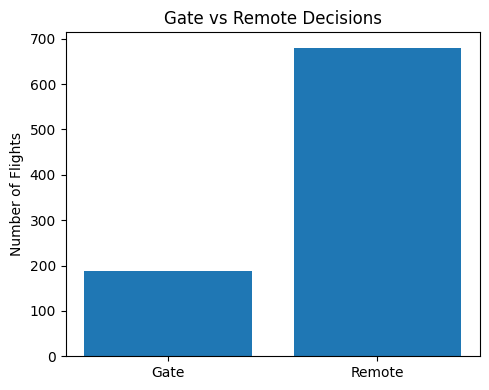

In [17]:
import matplotlib.pyplot as plt

# remote is 0/1
counts = df_results['remote'].value_counts().sort_index()
labels = ['Gate', 'Remote']

plt.figure(figsize=(5,4))
plt.bar(labels, [counts.get(0, 0), counts.get(1, 0)])
plt.title("Gate vs Remote Decisions")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig("gate_vs_remote.png", dpi=300)
plt.show()



The solution sends 188 flights to gates and 580 flights to remote stands, indicating that remote stands are still heavily used as a relief valve for limited gate and tug capacity. 

Our model most probably does that as the number of gates is limited (36 compared to 190 in real life), and also by the fact that we have 5 tugs available.

Unfortunately running these models take quite some time, even though we use heuristics, and relaxed a bit our hard constraints by discarding our distance matrix and taking a worst case scenario.

#### How many flights are sent to each gate?

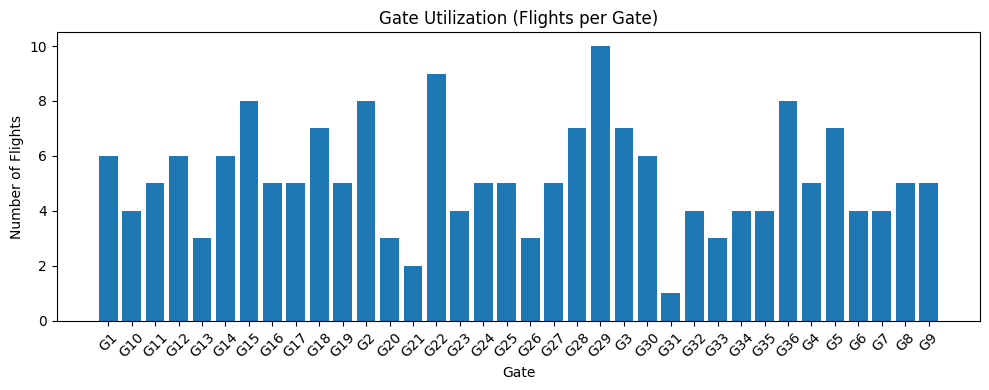

In [18]:
gate_counts = (
    df_results[df_results['remote'] == 0]['gate']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,4))
plt.bar(gate_counts.index.astype(str), gate_counts.values)
plt.title("Gate Utilization (Flights per Gate)")
plt.xlabel("Gate")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("gate_utilization.png", dpi=300)
plt.show()


#### How many flights per tug?

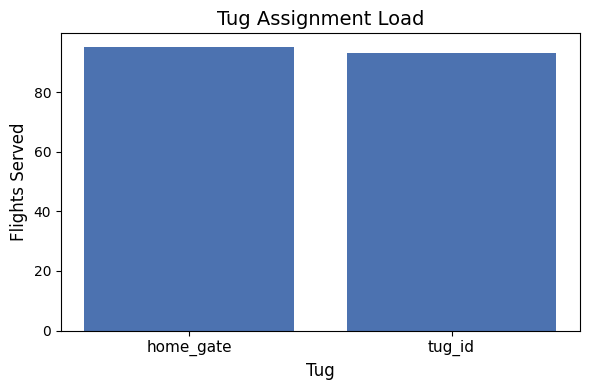

In [23]:
import matplotlib.pyplot as plt

df_results['tug_clean'] = df_results['tug'].replace({
    'home_gate': 'Tug A',
    'tug_id': 'Tug B'
})


# Convert tug labels to nicer names (optional)
tug_counts = (
    df_results[df_results['remote'] == 0]['tug']
    .value_counts()
    .rename_axis("Tug")
    .reset_index(name="Flights Served")
)

# Sort by flights served
tug_counts = tug_counts.sort_values("Flights Served", ascending=False)

plt.figure(figsize=(6,4))
plt.bar(tug_counts["Tug"], tug_counts["Flights Served"], color="#4C72B0")

plt.title("Tug Assignment Load", fontsize=14)
plt.xlabel("Tug", fontsize=12)
plt.ylabel("Flights Served", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()

plt.savefig("tug_load_clean.png", dpi=300)
plt.show()



#### Cost decomposition

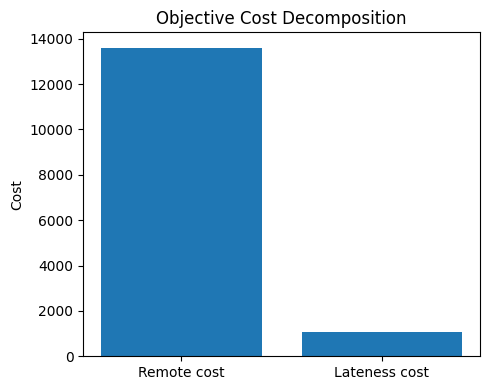

In [21]:
remote_cost = C_REMOTE * sum(y[f].X for f in flights)
late_cost   = C_LATE   * sum(L[f].X for f in flights)

labels = ['Remote cost', 'Lateness cost']
values = [remote_cost, late_cost]

plt.figure(figsize=(5,4))
plt.bar(labels, values)
plt.title("Objective Cost Decomposition")
plt.ylabel("Cost")
plt.tight_layout()
plt.savefig("cost_decomposition.png", dpi=300)
plt.show()


As most flights are sent to remote, most of the cost comes from here, and not many flights are late.

# Trying on a subset

In [16]:
# --- OVERLAP FOR THE SUBSET ---

# build dicts for arr/dep on the subset


arr_sub = visits_milp_sub.set_index("visit_id")["arr"].to_dict()
dep_sub = visits_milp_sub.set_index("visit_id")["dep"].to_dict()

subset_overlap_pairs = []
for i, f1 in enumerate(flights_sub):
    for f2 in flights_sub[i + 1:]:
        if arr_sub[f1] < dep_sub[f2] and arr_sub[f2] < dep_sub[f1]:
            subset_overlap_pairs.append((f1, f2))

print("Subset gate-overlap pairs:", len(subset_overlap_pairs))

# === 4-gate subset ===

# 1) Choose which 4 gates to keep
#    Here I just take the first 4 unique gate IDs; change this list if you want specific gates.
gate_ids_sub = list(gates["gate_id"].unique())[:10]
print("Chosen 10 gates:", gate_ids_sub)

# 2) DataFrame with only those gates (if you ever need gate metadata)
gates_sub = gates[gates["gate_id"].isin(gate_ids_sub)].copy()
gates_sub = gates_sub.drop_duplicates(subset=["gate_id"]).reset_index(drop=True)
print("gates_sub:\n", gates_sub)

# 3) List version for the MILP
gates_list_sub = gate_ids_sub
print("gates_list_sub:", gates_list_sub)

# 4) Distance matrix restricted to these 12 gates,
#    assuming your original `travel_time` is a dict keyed by (g1, g2)
travel_time_sub = {
    (g1, g2): travel_time[g1, g2]
    for g1 in gates_list_sub
    for g2 in gates_list_sub
}

print("Number of entries in travel_time_sub:", len(travel_time_sub))


tugs = ["T1", "T2","T3", "T4", "T5", "T6"]   # 6 tugs
print("Tugs:", tugs)



Subset gate-overlap pairs: 288
Chosen 10 gates: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
gates_sub:
   gate_id
0      G1
1      G2
2      G3
3      G4
4      G5
5      G6
6      G7
7      G8
8      G9
9     G10
gates_list_sub: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Number of entries in travel_time_sub: 100
Tugs: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6']


In [18]:
# variable counts
print("Subset sizes:")
print("  |F_sub| =", len(flights_sub))
print("  |G|     =", len(gates_list_sub))
print("  |K|     =", len(tugs))

print(" G squared * F_sub squared =", len(gates_list_sub)**2 * len(flights_sub)**2)

Subset sizes:
  |F_sub| = 35
  |G|     = 10
  |K|     = 6
 G squared * F_sub squared = 122500


In [41]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import pickle, datetime

# -----------------------------
# Data & params for SUBSET
# -----------------------------
dep_sched_sub = dep_sub   # if you want something else, change here

C_REMOTE = 200.0
C_LATE   = 1.0
SERVICE_TIME = 7.0  # minutes

max_dep_sub    = max(dep_sched_sub[f] for f in flights_sub)
max_travel_sub = max(travel_time[g1, g2] for g1 in gates_list_sub for g2 in gates_list_sub)
M_sub          = max_dep_sub + SERVICE_TIME + max_travel_sub

print("Subset sizes:")
print("  |F_sub| =", len(flights_sub))
print("  |G|     =", len(gates_list_sub))
print("  |K|     =", len(tugs))
print("M_sub =", M_sub)

# -----------------------------
# Save subset inputs (safety)
# -----------------------------
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
input_filename = f"atl_model2_subset_inputs_{timestamp}.pkl"

state_sub = {
    "flights_sub":        list(flights_sub),
    "gates_list_sub":         list(gates_list_sub),
    "tugs":               list(tugs),
    "dep_sched_sub":      dict(dep_sched_sub),
    "subset_overlap_pairs": list(subset_overlap_pairs),
    "travel_time_sub":        dict(travel_time_sub),
    "C_REMOTE":           C_REMOTE,
    "C_LATE":             C_LATE,
    "SERVICE_TIME":       SERVICE_TIME,
    "M_sub":              M_sub,
}
with open(input_filename, "wb") as f:
    pickle.dump(state_sub, f)

print("Saved subset inputs to", input_filename)

# -----------------------------
# Build subset model
# -----------------------------
model2_sub = gp.Model("Gate_and_Tug_Assignment_with_TravelTime_SUBSET")

# Decision variables (ONLY subset)
x_sub = model2_sub.addVars(flights_sub, gates_list_sub, vtype=GRB.BINARY,    name="x")
y_sub = model2_sub.addVars(flights_sub,              vtype=GRB.BINARY,   name="y")
z_sub = model2_sub.addVars(flights_sub, tugs,        vtype=GRB.BINARY,   name="z")
s_sub = model2_sub.addVars(flights_sub,              vtype=GRB.CONTINUOUS, name="s")
L_sub = model2_sub.addVars(flights_sub,              vtype=GRB.CONTINUOUS, name="L")

u_sub = model2_sub.addVars(
    [(f1, f2, k)
     for f1 in flights_sub
     for f2 in flights_sub if f1 != f2
     for k in tugs],
    vtype=GRB.BINARY,
    name="u"
)

w_sub = model2_sub.addVars(
    [(f1, f2, g1, g2)
     for f1 in flights_sub
     for f2 in flights_sub if f1 != f2
     for g1 in gates_list_sub
     for g2 in gates_list_sub],
    vtype=GRB.BINARY,
    name="w"
)

# -----------------------------
# Constraints (subset)
# -----------------------------

# 1. Gate OR remote
for f in flights_sub:
    model2_sub.addConstr(
        gp.quicksum(x_sub[f, g] for g in gates_list_sub) + y_sub[f] == 1,
        name=f"assign_gate_or_remote_{f}"
    )

# 2. Gate capacity on subset
for (f1, f2) in subset_overlap_pairs:
    for g in gates_list_sub:
        model2_sub.addConstr(
            x_sub[f1, g] + x_sub[f2, g] <= 1,
            name=f"gate_overlap_{f1}_{f2}_{g}"
        )

# 3. Tug assignment
for f in flights_sub:
    model2_sub.addConstr(
        gp.quicksum(z_sub[f, k] for k in tugs) == 1 - y_sub[f],
        name=f"tug_assign_{f}"
    )

# 4. Pushback time & lateness
for f in flights_sub:
    model2_sub.addConstr(
        s_sub[f] >= dep_sched_sub[f],
        name=f"no_early_pushback_{f}"
    )
    model2_sub.addConstr(
        L_sub[f] >= s_sub[f] - dep_sched_sub[f],
        name=f"lateness_def_{f}"
    )

# 5. Gate-pair consistency for w  (FIXED)
for f1 in flights_sub:
    for f2 in flights_sub:
        if f1 == f2:
            continue

        # (a) link each w to the corresponding gate choices
        for g1 in gates_list_sub:
            for g2 in gates_list_sub:
                model2_sub.addConstr(
                    w_sub[f1, f2, g1, g2] <= x_sub[f1, g1],
                    name=f"w_le_x1_{f1}_{f2}_{g1}_{g2}"
                )
                model2_sub.addConstr(
                    w_sub[f1, f2, g1, g2] <= x_sub[f2, g2],
                    name=f"w_le_x2_{f1}_{f2}_{g1}_{g2}"
                )

        # (b) aggregated "AND" logic:
        # sum_w is 1 if both flights are gate flights, 0 otherwise
        sum_w = gp.quicksum(
            w_sub[f1, f2, g1, g2]
            for g1 in gates_list_sub for g2 in gates_list_sub
        )

        model2_sub.addConstr(
            sum_w <= gp.quicksum(x_sub[f1, g1] for g1 in gates_list_sub),
            name=f"w_sum_le_x1_{f1}_{f2}"
        )
        model2_sub.addConstr(
            sum_w <= gp.quicksum(x_sub[f2, g2] for g2 in gates_list_sub),
            name=f"w_sum_le_x2_{f1}_{f2}"
        )
        model2_sub.addConstr(
            sum_w >= gp.quicksum(x_sub[f1, g1] for g1 in gates_list_sub)
                     + gp.quicksum(x_sub[f2, g2] for g2 in gates_list_sub)
                     - 1,
            name=f"w_sum_ge_and_{f1}_{f2}"
        )


# 6. Order variables only active when tug k serves both flights
for f1 in flights_sub:
    for f2 in flights_sub:
        if f1 == f2:
            continue
        for k in tugs:
            model2_sub.addConstr(
                u_sub[f1, f2, k] <= z_sub[f1, k],
                name=f"u_le_z1_{f1}_{f2}_{k}"
            )
            model2_sub.addConstr(
                u_sub[f1, f2, k] <= z_sub[f2, k],
                name=f"u_le_z2_{f1}_{f2}_{k}"
            )
            model2_sub.addConstr(
                z_sub[f1, k] + z_sub[f2, k] - 1
                <= u_sub[f1, f2, k] + u_sub[f2, f1, k],
                name=f"order_consistency_{f1}_{f2}_{k}"
            )

# 7. Travel-time-based sequencing
for f1 in flights_sub:
    for f2 in flights_sub:
        if f1 == f2:
            continue
        for k in tugs:
            model2_sub.addConstr(
                s_sub[f2] >=
                s_sub[f1]
                + SERVICE_TIME
                + gp.quicksum(
                    travel_time_sub[g1, g2] * w_sub[f1, f2, g1, g2]
                    for g1 in gates_list_sub for g2 in gates_list_sub
                )
                - M_sub * (1 - u_sub[f1, f2, k]),
                name=f"travel_time_seq_{f1}_{f2}_{k}"
            )

# -----------------------------
# Objective
# -----------------------------
model2_sub.setObjective(
    C_REMOTE * gp.quicksum(y_sub[f] for f in flights_sub)
    + C_LATE   * gp.quicksum(L_sub[f] for f in flights_sub),
    GRB.MINIMIZE
)

# -----------------------------
# Count binaries (subset)
# -----------------------------
F = len(flights_sub)
G = len(gates_list_sub)
K = len(tugs)

num_x = F * G
num_y = F
num_z = F * K

# Gurobi params + logs
# -----------------------------
gp.setParam('OutputFlag', 1)
gp.setParam('LogToConsole', 1)

model2_sub.Params.MIPFocus       = 1
model2_sub.Params.Heuristics     = 0.8
#model2_sub.Params.Cuts           = 0
model2_sub.Params.Presolve       = 1
model2_sub.Params.TimeLimit      = 5400
model2_sub.Params.OutputFlag     = 1
model2_sub.Params.LogToConsole   = 1
model2_sub.Params.DisplayInterval = 1
model2_sub.Params.LogFile        = ""

lp_filename = f"atl_model2_subset_{timestamp}.lp"
model2_sub.write(lp_filename)
print("Wrote LP model to", lp_filename)

# -----------------------------
# Optimize and save solution
# -----------------------------
print(">>> Starting optimize on subset...")
model2_sub.optimize()
print(">>> Finished optimize on subset.")
print("Status:", model2_sub.Status)

if model2_sub.Status in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
    print("Objective value:", model2_sub.ObjVal)

    rows = []
    for f in flights_sub:
        # gate (first gate with x_sub[f,g] = 1)
        gate_assigned = None
        for g in gates_list_sub:
            if x_sub[f, g].X > 0.5:
                gate_assigned = g
                break

        # tug (first tug with z_sub[f,k] = 1, if not remote)
        tug_assigned = None
        if y_sub[f].X < 0.5:
            for k in tugs:
                if z_sub[f, k].X > 0.5:
                    tug_assigned = k
                    break

        rows.append({
            "flight":        f,
            "gate":          gate_assigned,
            "remote":        int(round(y_sub[f].X)),
            "tug":           tug_assigned,
            "pushback_time": s_sub[f].X,
            "lateness":      L_sub[f].X,
        })

    df_results_sub = pd.DataFrame(rows)
    sol_csv = f"atl_model2_subset_solution_{timestamp}.csv"
    df_results_sub.to_csv(sol_csv, index=False)
    print("Saved subset solution to", sol_csv)


Subset sizes:
  |F_sub| = 35
  |G|     = 10
  |K|     = 6
M_sub = 1360.24
Saved subset inputs to atl_model2_subset_inputs_20251205_220155.pkl
Set parameter OutputFlag to value 1
Set parameter OutputFlag to value 1
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter LogToConsole to value 1
Set parameter LogToConsole to value 1
Set parameter MIPFocus to value 1
Set parameter Heuristics to value 0.8
Set parameter Presolve to value 1
Set parameter TimeLimit to value 5400
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter DisplayInterval to value 1
Set parameter LogFile to value ""
Wrote LP model to atl_model2_subset_20251205_220155.lp
>>> Starting optimize on subset...
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[rosetta2] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  5400
Heuristics  0.8
MIPFocu

In [42]:
# Extracting df results sub
import pandas as pd
rows = []
for f in flights_sub:
    # gate (first gate with x_sub[f,g] = 1) 
    gate = next((g for g in gates_list_sub if x_sub[f, g].X > 0.5), None)
    rows.append({
        "flight": f,
        "gate": gate,
        "remote": y_sub[f].X,
        "tug": next((k for k in tugs if z_sub[f, k].X > 0.5), None),
        "pushback_time": s_sub[f].X,
        "lateness": L_sub[f].X
    })

df_results_sub = pd.DataFrame(rows)

In [43]:
# ---------- 1. Merge with arr/dep and sort ----------
vis_sub_for_merge = visits_milp_sub[["visit_id", "arr", "dep"]].rename(
    columns={"visit_id": "flight"}
)

df_full = (
    df_results_sub
    .merge(vis_sub_for_merge, on="flight", how="left")
    .sort_values("dep")
)

pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)

print("=== Detailed results for subset model ===")
display(df_full)        # or print(df_full) if display() not available

# ---------- 2. Basic assignment summaries ----------
print("\n=== Assignment summary ===")
print("Total flights:", len(df_results_sub))
print("Gate flights:", (df_results_sub["remote"] == 0).sum())
print("Remote flights:", (df_results_sub["remote"] == 1).sum())

print("\nFlights per gate:")
print(df_results_sub["gate"].value_counts(dropna=False))

print("\nFlights per tug (gate flights only):")
print(
    df_results_sub.loc[df_results_sub["remote"] == 0, "tug"]
    .value_counts(dropna=False)
)

# ---------- 3. Tug sequence view (sorted by pushback) ----------
print("\n=== Tug schedule (gate flights only, sorted by time) ===")
tug_schedule = (
    df_full[df_full["remote"] == 0]
    .sort_values("pushback_time")
    [["flight", "gate", "tug", "arr", "dep", "pushback_time", "lateness"]]
)

display(tug_schedule)

# ---------- 4. Cost breakdown ----------
remote_cost = C_REMOTE * df_results_sub["remote"].sum()
late_cost   = C_LATE   * df_results_sub["lateness"].sum()

print("\n=== Cost breakdown ===")
print(f"Remote flights cost: {remote_cost:.1f}")
print(f"Lateness cost:       {late_cost:.1f}")
print(f"Total objective:     {remote_cost + late_cost:.1f}")


=== Detailed results for subset model ===


,flight,gate,remote,tug,pushback_time,lateness,arr,dep
0,5,G7,-0.0,T4,980.0,0.0,918,980
25,202,G10,0.0,T1,983.0,0.0,933,983
16,139,G1,0.0,T2,991.0,0.0,939,991
28,213,G3,0.0,T5,993.0,0.0,906,993
3,33,G9,0.0,T4,1000.0,0.0,914,1000
19,167,G8,0.0,T3,1006.0,0.0,538,1006
11,82,G2,-0.0,T4,1025.0,0.0,549,1025
24,198,None,1.0,None,1030.0,0.0,973,1030
29,224,G5,0.0,T6,1037.0,0.0,758,1037
20,168,G4,-0.0,T5,1041.0,0.0,964,1041



=== Assignment summary ===
Total flights: 35
Gate flights: 30
Remote flights: 5

Flights per gate:
gate
None    5
G10     4
G8      4
G7      3
G9      3
G2      3
G1      3
G5      3
G3      3
G6      2
G4      2
Name: count, dtype: int64

Flights per tug (gate flights only):
tug
T4    7
T5    6
T6    5
T2    4
T3    4
T1    4
Name: count, dtype: int64

=== Tug schedule (gate flights only, sorted by time) ===


,flight,gate,tug,arr,dep,pushback_time,lateness
0,5,G7,T4,918,980,980.0,0.0
25,202,G10,T1,933,983,983.0,0.0
16,139,G1,T2,939,991,991.0,0.0
28,213,G3,T5,906,993,993.0,0.0
3,33,G9,T4,914,1000,1000.0,0.0
19,167,G8,T3,538,1006,1006.0,0.0
11,82,G2,T4,549,1025,1025.0,0.0
29,224,G5,T6,758,1037,1037.0,0.0
20,168,G4,T5,964,1041,1041.0,0.0
17,143,G7,T1,986,1052,1052.0,0.0



=== Cost breakdown ===
Remote flights cost: 1000.0
Lateness cost:       0.0
Total objective:     1000.0


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Merge results with arr/dep
vis_sub_for_merge = visits_milp_sub[["visit_id", "arr", "dep"]].rename(
    columns={"visit_id": "flight"}
)

df_full = (
    df_results_sub
    .merge(vis_sub_for_merge, on="flight", how="left")
    .sort_values("dep")
)




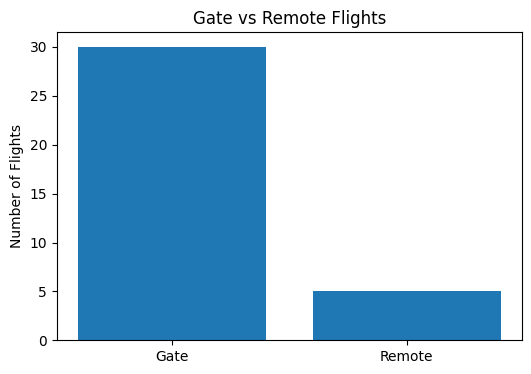

In [45]:
plt.figure(figsize=(6,4))
values = [
    (df_results_sub["remote"] == 0).sum(),   # gate flights
    (df_results_sub["remote"] == 1).sum()    # remote flights
]
plt.bar(["Gate", "Remote"], values)
plt.title("Gate vs Remote Flights")
plt.ylabel("Number of Flights")
plt.show()


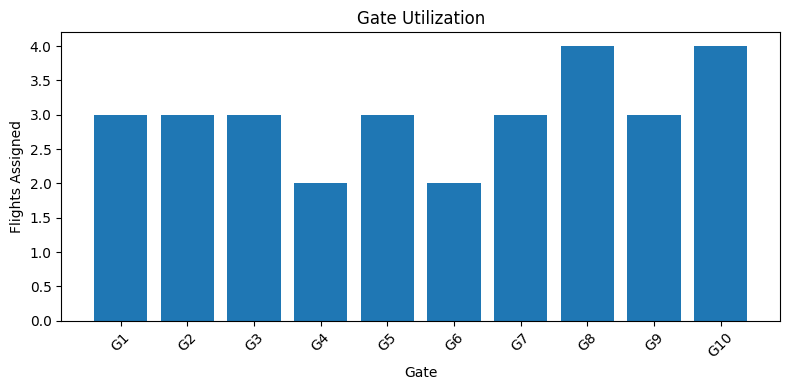

In [47]:
gate_counts = (
    df_results_sub[df_results_sub["remote"] == 0]
    .groupby("gate")["flight"]
    .count()
    .reindex(gates_list_sub, fill_value=0)
)

plt.figure(figsize=(8,4))
plt.bar(gate_counts.index.astype(str), gate_counts.values)
plt.title("Gate Utilization")
plt.xlabel("Gate")
plt.ylabel("Flights Assigned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


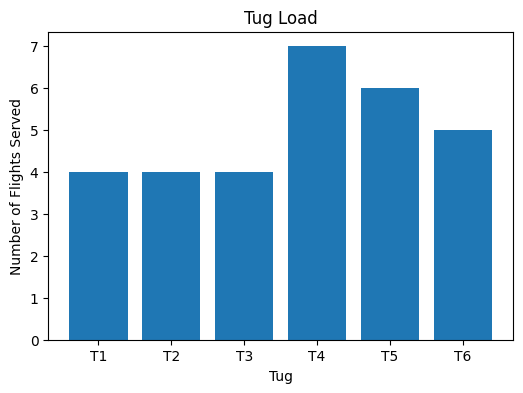

In [48]:
tug_counts = (
    df_results_sub[df_results_sub["remote"] == 0]
    .groupby("tug")["flight"]
    .count()
    .reindex(tugs, fill_value=0)
)

plt.figure(figsize=(6,4))
plt.bar(tug_counts.index.astype(str), tug_counts.values)
plt.title("Tug Load")
plt.xlabel("Tug")
plt.ylabel("Number of Flights Served")
plt.show()


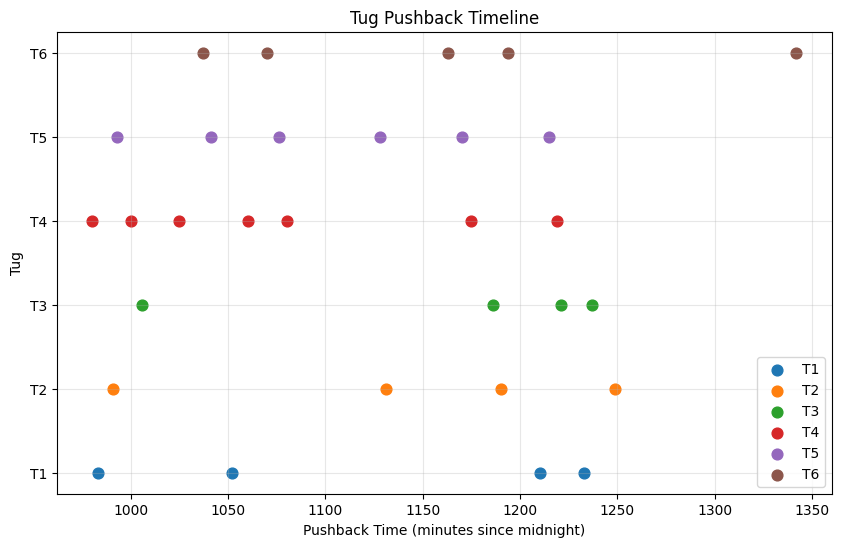

In [49]:
plt.figure(figsize=(10,6))

for k in tugs:
    sub = df_full[(df_full["tug"] == k) & (df_full["remote"] == 0)]
    plt.scatter(sub["pushback_time"], [k]*len(sub), s=60, label=k)

plt.title("Tug Pushback Timeline")
plt.xlabel("Pushback Time (minutes since midnight)")
plt.ylabel("Tug")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


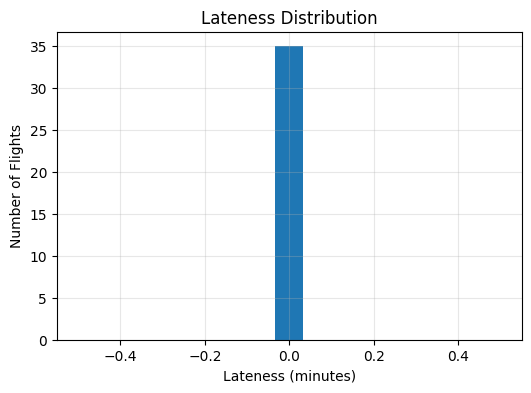

In [50]:
plt.figure(figsize=(6,4))
plt.hist(df_results_sub["lateness"], bins=15)
plt.title("Lateness Distribution")
plt.xlabel("Lateness (minutes)")
plt.ylabel("Number of Flights")
plt.grid(True, alpha=0.3)
plt.show()


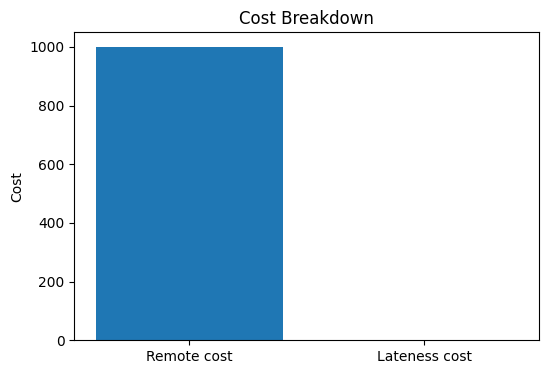

In [51]:
remote_cost = C_REMOTE * df_results_sub["remote"].sum()
late_cost   = C_LATE   * df_results_sub["lateness"].sum()

plt.figure(figsize=(6,4))
plt.bar(["Remote cost", "Lateness cost"], [remote_cost, late_cost])
plt.title("Cost Breakdown")
plt.ylabel("Cost")
plt.show()


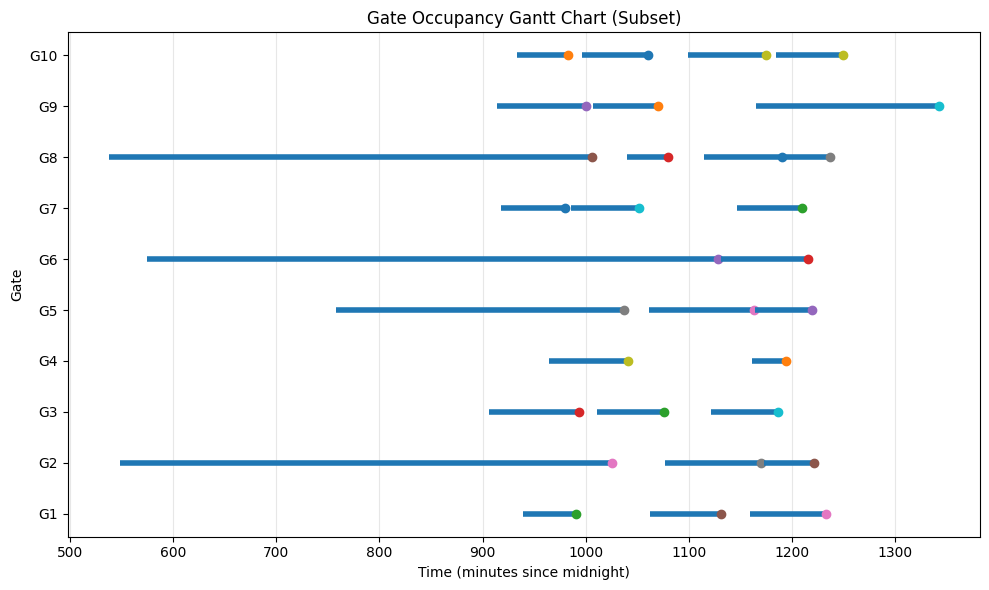

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Filter to gate flights only
df_gate = df_full[df_full["remote"] == 0].copy()

# Map gates to numeric y positions
gate_to_y = {g: i for i, g in enumerate(gates_list_sub)}
df_gate["y"] = df_gate["gate"].map(gate_to_y)

plt.figure(figsize=(10, 6))

for _, row in df_gate.iterrows():
    plt.hlines(
        y=row["y"],
        xmin=row["arr"],
        xmax=row["dep"],
        linewidth=4,
    )
    # optional: mark pushback
    plt.plot(row["pushback_time"], row["y"], marker="o")

plt.yticks(
    list(gate_to_y.values()),
    [str(g) for g in gates_list_sub]
)
plt.xlabel("Time (minutes since midnight)")
plt.ylabel("Gate")
plt.title("Gate Occupancy Gantt Chart (Subset)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


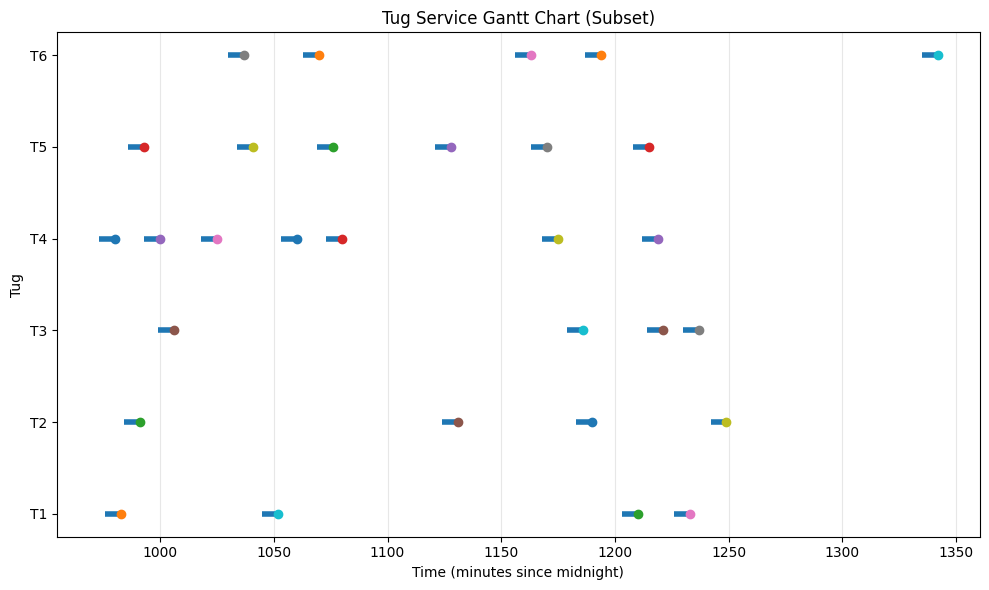

In [53]:
df_tug = df_full[(df_full["remote"] == 0) & df_full["tug"].notna()].copy()

tug_to_y = {k: i for i, k in enumerate(tugs)}
df_tug["y"] = df_tug["tug"].map(tug_to_y)

plt.figure(figsize=(10, 6))

for _, row in df_tug.iterrows():
    start = row["pushback_time"] - SERVICE_TIME
    end   = row["pushback_time"]
    plt.hlines(
        y=row["y"],
        xmin=start,
        xmax=end,
        linewidth=4,
    )
    plt.plot(row["pushback_time"], row["y"], marker="o")

plt.yticks(
    list(tug_to_y.values()),
    [str(k) for k in tugs]
)
plt.xlabel("Time (minutes since midnight)")
plt.ylabel("Tug")
plt.title("Tug Service Gantt Chart (Subset)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


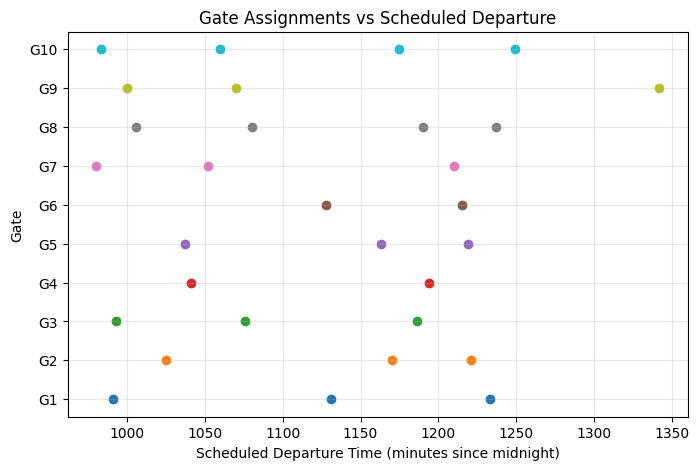

In [54]:
df_gate = df_full[df_full["remote"] == 0].copy()

plt.figure(figsize=(8, 5))
for g in gates_list_sub:
    sub = df_gate[df_gate["gate"] == g]
    plt.scatter(sub["dep"], [str(g)] * len(sub), label=str(g))

plt.xlabel("Scheduled Departure Time (minutes since midnight)")
plt.ylabel("Gate")
plt.title("Gate Assignments vs Scheduled Departure")
plt.grid(True, alpha=0.3)
plt.show()
